In [91]:
# Importation des librairies de base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import argparse

# Données
import wrds

#2.1
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from sklearn.metrics import mean_squared_error

#2.2
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

#2.3 
import statsmodels.api as sm

# 2.4
from dataclasses import dataclass

In [92]:
db = wrds.Connection(wrds_username='lilas_bertot')

Loading library list...
Done
Done


In [93]:
import warnings
warnings.filterwarnings('ignore')

# PRÉPARATION DES DONNÉES

In [94]:
spx_query = """
SELECT date, spindx as prc
FROM crsp.dsi
WHERE date >= '2010-01-01'
AND spindx IS NOT NULL
ORDER BY date;
"""
spx_data = db.raw_sql(spx_query, date_cols=['date'])
spx_data = spx_data.rename(columns={'prc': 'SP500'})
spx_data['date'] = pd.to_datetime(spx_data['date'])

print(spx_data)
print("Nombre d’observations :", len(spx_data))

           date    SP500
0    2010-01-04  1132.99
1    2010-01-05  1136.52
2    2010-01-06  1137.14
3    2010-01-07  1141.69
4    2010-01-08  1144.98
...         ...      ...
3769 2024-12-24  6040.04
3770 2024-12-26  6037.59
3771 2024-12-27  5970.84
3772 2024-12-30  5906.94
3773 2024-12-31  5881.63

[3774 rows x 2 columns]
Nombre d’observations : 3774


In [95]:
# téléchargement indices boursier 3 marchés développés: DAX (Allemagne), Nikkei225 (Japon), FTSE100 (Royaume-Uni)
# téléchargement indices boursier 2 marchés émergents: Bovespa (Brésil), Nifty50 (Inde)

intern_indices_query = """
SELECT 
    datadate,
    MAX(CASE WHEN gvkeyx = '150095' THEN prccd END) AS DAX,
    MAX(CASE WHEN gvkeyx = '150008' THEN prccd END) AS FTSE100,
    MAX(CASE WHEN gvkeyx = '150069' THEN prccd END) AS Nikkei225,
    MAX(CASE WHEN gvkeyx = '150086' THEN prccd END) AS Bovespa,
    MAX(CASE WHEN gvkeyx = '151120' THEN prccd END) AS Nifty50
FROM comp.g_idx_daily
WHERE gvkeyx IN ('150095', '150008', '150069', '150086', '151120')
  AND datadate >= '2010-01-01'
  AND prccd IS NOT NULL
GROUP BY datadate
ORDER BY datadate
"""
intern_indices_data = db.raw_sql(intern_indices_query, date_cols=['datadate'])
intern_indices_data['datadate'] = pd.to_datetime(intern_indices_data['datadate'])

intern_indices_data.columns = ['datadate', 'DAX', 'FTSE100', 'Nikkei225', 'Bovespa', 'Nifty50']

print(intern_indices_data)
print("Nombre d’observations :", len(intern_indices_data))

       datadate       DAX    FTSE100  Nikkei225    Bovespa  Nifty50
0    2010-01-01   5957.43    5412.88   10546.44   68588.41  5201.05
1    2010-01-04    6048.3    5500.34   10654.79   70045.08   5232.2
2    2010-01-05   6031.86     5522.5   10681.83   70239.82   5277.9
3    2010-01-06   6034.33    5530.04   10731.45   70729.34   5281.8
4    2010-01-07   6019.36    5526.72   10681.66   70451.12   5263.1
...         ...       ...        ...        ...        ...      ...
4145 2025-11-05  24049.74   9777.085   50212.27  153294.44  25597.7
4146 2025-11-06  23734.02  9735.7842   50883.68  153338.63  25509.7
4147 2025-11-07  23569.96  9682.5741   50276.37  154063.53  25492.3
4148 2025-11-10  23959.99  9787.1465   50911.76  155257.31  25574.3
4149 2025-11-11  24088.06  9899.5997   50842.93   157748.6  25695.0

[4150 rows x 6 columns]
Nombre d’observations : 4150


In [96]:
data_dict = {
    'DAX': intern_indices_data[['DAX']],
    'FTSE100': intern_indices_data[['FTSE100']],
    'NIKKEI225': intern_indices_data[['Nikkei225']],
    'BOVESPA': intern_indices_data[['Bovespa']],
    'NIFTY50': intern_indices_data[['Nifty50']]
}

# SP500 comme base
spx_df = spx_data.set_index('date')[['SP500']]

# Fusionner sur toutes les dates communes (car différents fériés, etc.)
all_data = spx_df.copy()
for name, df in data_dict.items():
    df = df.set_index(intern_indices_data['datadate']) 
    all_data = all_data.join(df, how='inner')

common_dates = all_data.dropna().index
all_data = all_data.loc[common_dates]

print("Données fusionnées :")
print(all_data)

print("Nombre d’observations par indice après la fusion des données :")
print(all_data.count())

print("Période couverte par tous les indices :")
print(all_data.index.min().date(), "à", all_data.index.max().date())

Données fusionnées :
              SP500       DAX    FTSE100  Nikkei225    Bovespa  Nifty50
2010-01-04  1132.99    6048.3    5500.34   10654.79   70045.08   5232.2
2010-01-05  1136.52   6031.86     5522.5   10681.83   70239.82   5277.9
2010-01-06  1137.14   6034.33    5530.04   10731.45   70729.34   5281.8
2010-01-07  1141.69   6019.36    5526.72   10681.66   70451.12   5263.1
2010-01-08  1144.98   6037.61    5534.24   10798.32    70262.7  5244.75
...             ...       ...        ...        ...        ...      ...
2024-12-24  6040.04  19848.77  8136.9933   39036.85  120766.57  23727.7
2024-12-26  6037.59  19848.77  8136.9933   39568.06   121077.5  23750.2
2024-12-27  5970.84  19984.32  8149.7804   40281.16  120269.31  23813.4
2024-12-30  5906.94  19909.14  8121.0077   39894.54   120283.4  23644.9
2024-12-31  5881.63  19909.14  8173.0239   39894.54   120283.4  23644.8

[3773 rows x 6 columns]
Nombre d’observations par indice après la fusion des données :
SP500        3773
DAX      

# PARTIE 2.1

##### Étapes à suivre 
- Calcul des rendements (faire graphique pour visualiser la volatilité et "deviner" visuellement le degré de corrélation);
- Calcul des corrélations mobiles entre SP500 et autres indices internationaux (faire graphique pour interprétation visuelle);
- Établir les statistiques descriptives de chaque série de corrélation pour interprétation;
- Autocorrélation à lag 1 pour voir la persistance temporelle;
- Détecter la stationnarité de chaque série;
- Interprétation

In [97]:
# Calcul rendements journaliers 
returns = np.log(all_data / all_data.shift(1))
returns = returns.dropna(how="any")

print("Aperçu rendements :")
print(returns)

Aperçu rendements :
               SP500       DAX   FTSE100  Nikkei225   Bovespa   Nifty50
2010-01-05  0.003111 -0.002722  0.004021   0.002535  0.002776  0.008696
2010-01-06  0.000545  0.000409  0.001364   0.004635  0.006945  0.000739
2010-01-07  0.003993 -0.002484 -0.000601   -0.00465 -0.003941 -0.003547
2010-01-08  0.002878  0.003027   0.00136   0.010862 -0.002678 -0.003493
2010-01-11  0.001745  0.000479  0.000692        0.0  0.002428  0.000886
...              ...       ...       ...        ...       ...       ...
2024-12-24  0.010982       0.0  0.004221  -0.003184       0.0 -0.001085
2024-12-26 -0.000406       0.0       0.0   0.013516  0.002571  0.000948
2024-12-27 -0.011117  0.006806   0.00157   0.017862 -0.006697  0.002657
2024-12-30  -0.01076 -0.003769 -0.003537  -0.009644  0.000117 -0.007101
2024-12-31 -0.004294       0.0  0.006385        0.0       0.0 -0.000004

[3772 rows x 6 columns]


<Figure size 1200x600 with 0 Axes>

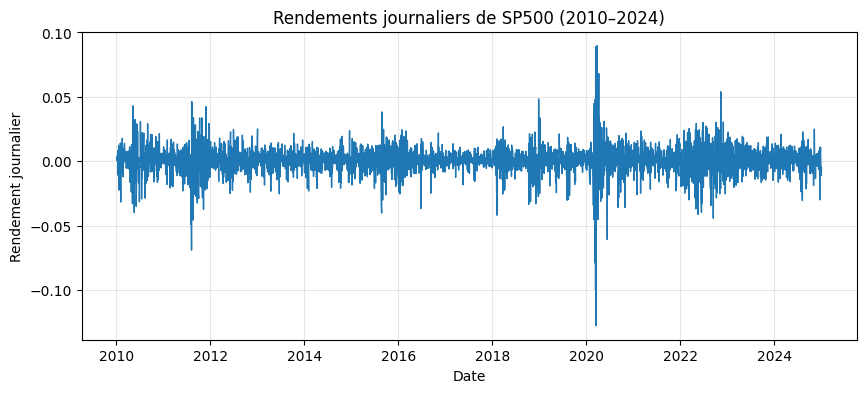

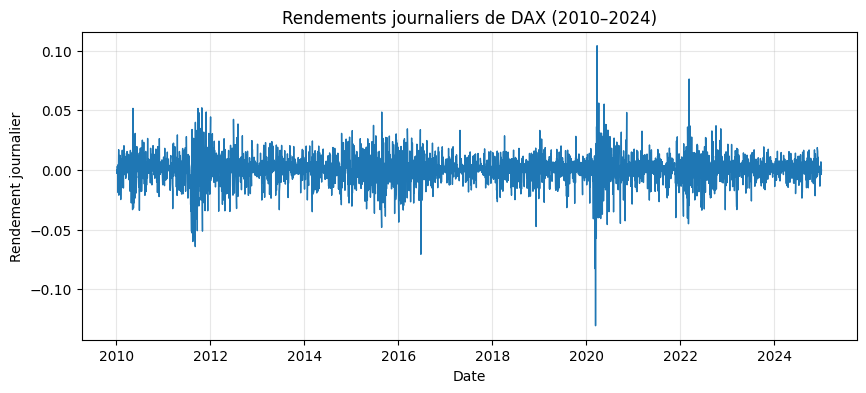

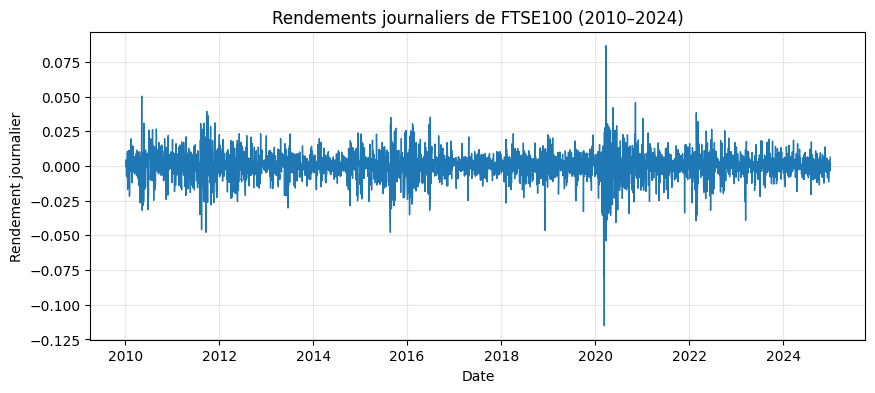

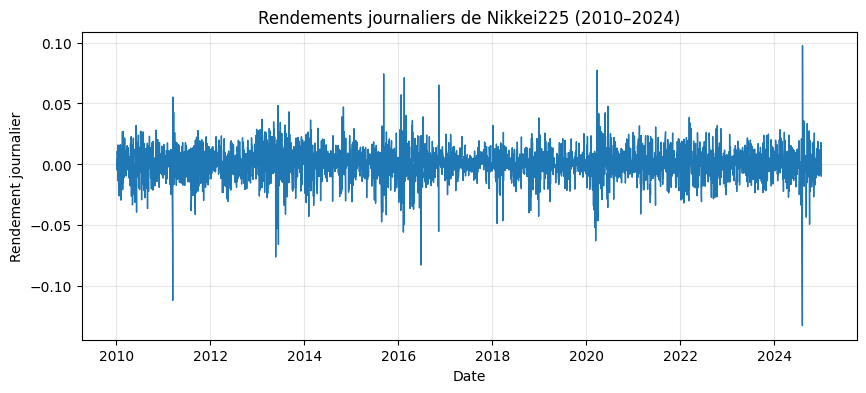

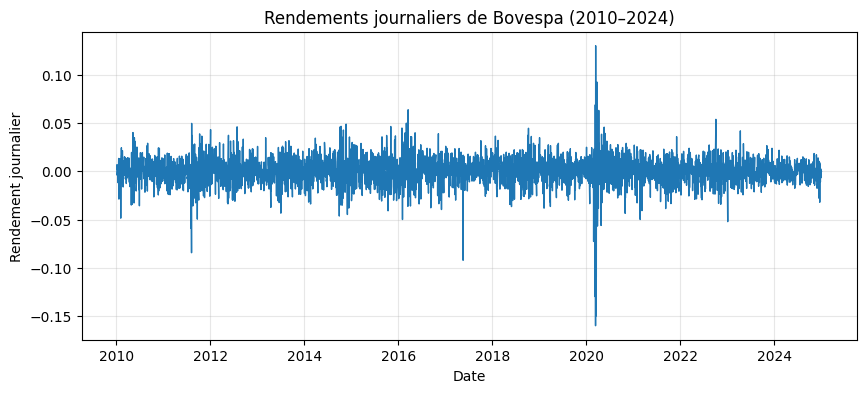

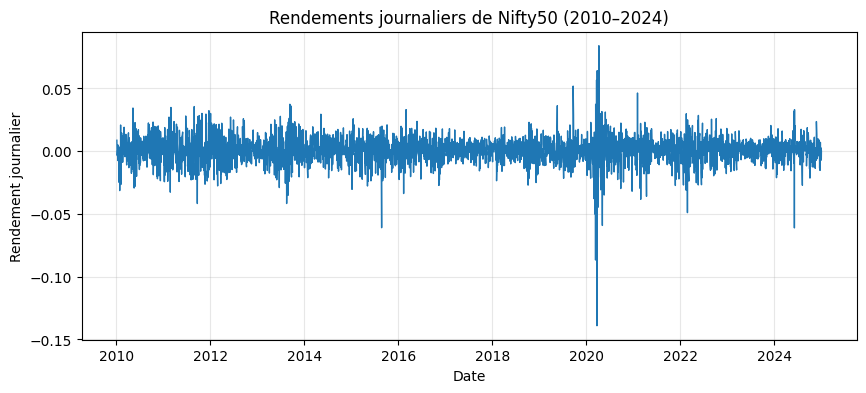

In [98]:
# Graphique des rendements journaliers
plt.figure(figsize=(12,6))
for col in returns.columns:
    plt.figure(figsize=(10, 4))
    plt.plot(returns.index, returns[col], color='tab:blue', linewidth=1)
    plt.title(f"Rendements journaliers de {col} (2010–2024)")
    plt.xlabel("Date")
    plt.ylabel("Rendement journalier")
    plt.grid(True, alpha=0.3)
    plt.show()

In [99]:
# fenêtre 126 jours comme demandé
WIN = 126 

# Corrélation mobile entre SP500 et chaque autre indice
corr_cols = ['DAX','Nikkei225','FTSE100','Bovespa','Nifty50']
corr_mob = pd.DataFrame(index=returns.index)

for col in corr_cols:
    corr_mob[f'corr_SP500_{col}'] = returns['SP500'].rolling(WIN).corr(returns[col])

corr_mob = corr_mob.dropna()

print("Corrélations mobiles (126j) :")
print(corr_mob)
print("\nNombre d'observations par série de corrélation :")
print(corr_mob.count())

Corrélations mobiles (126j) :
            corr_SP500_DAX  corr_SP500_Nikkei225  corr_SP500_FTSE100  \
2010-07-06        0.635893              0.210762            0.652437   
2010-07-07        0.633235              0.197942            0.651739   
2010-07-08        0.634284              0.206302            0.653415   
2010-07-09        0.635668              0.208772            0.654471   
2010-07-12        0.635538              0.207499            0.653911   
...                    ...                   ...                 ...   
2024-12-24        0.447845              0.369157            0.364970   
2024-12-26        0.447994              0.368094            0.366220   
2024-12-27        0.437256              0.357290            0.360101   
2024-12-30        0.439044              0.359404            0.363076   
2024-12-31        0.445482              0.357310            0.362917   

            corr_SP500_Bovespa  corr_SP500_Nifty50  
2010-07-06            0.770152            0.326947  

<Figure size 1200x600 with 0 Axes>

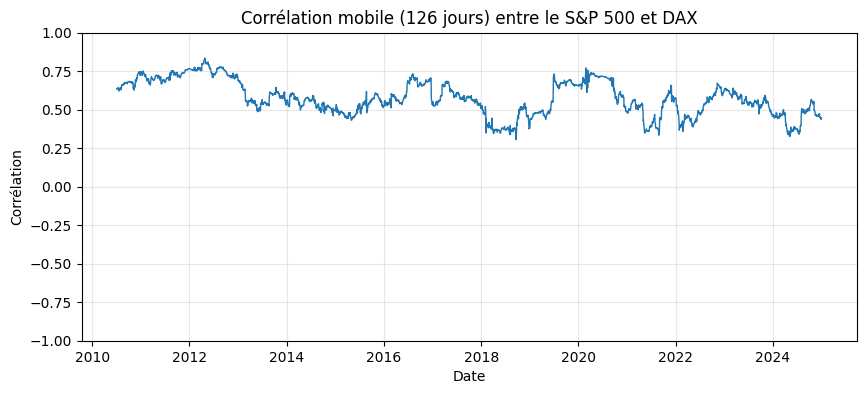

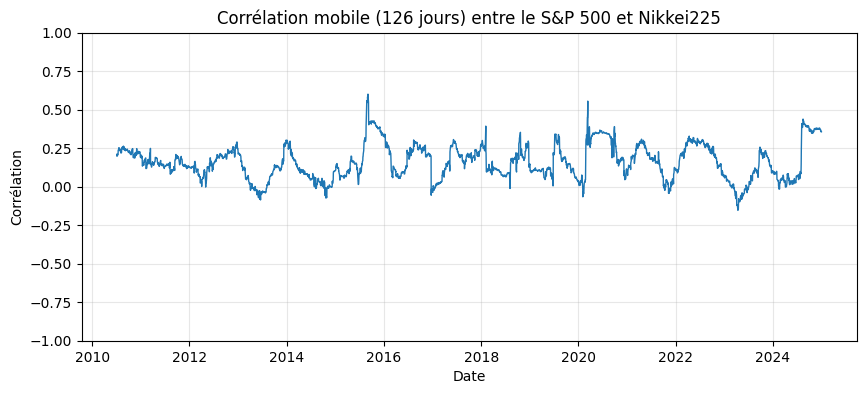

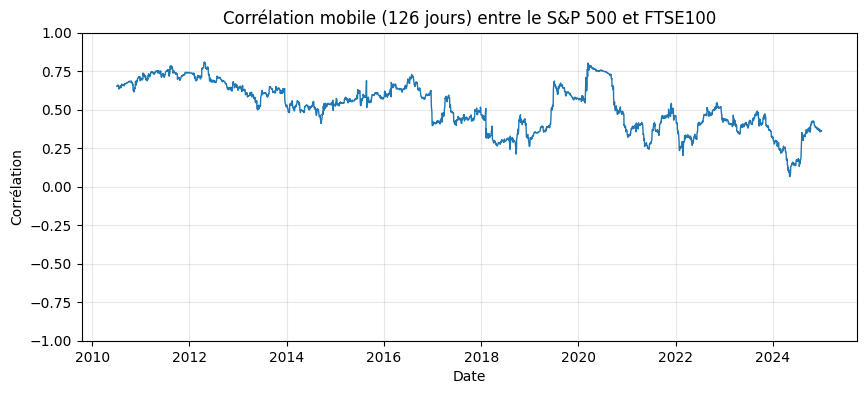

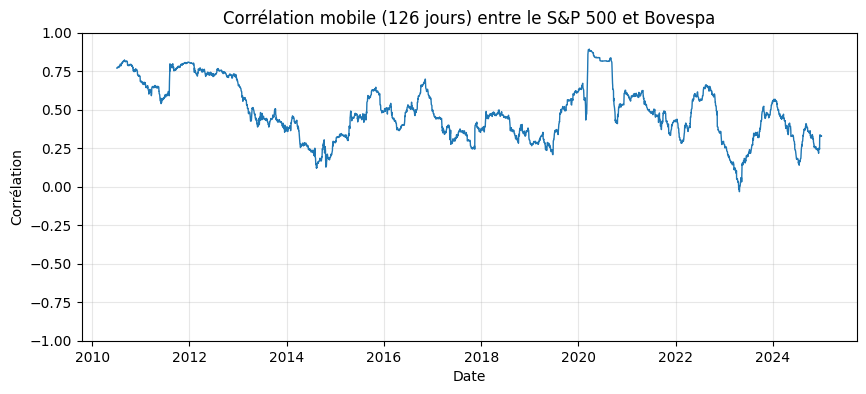

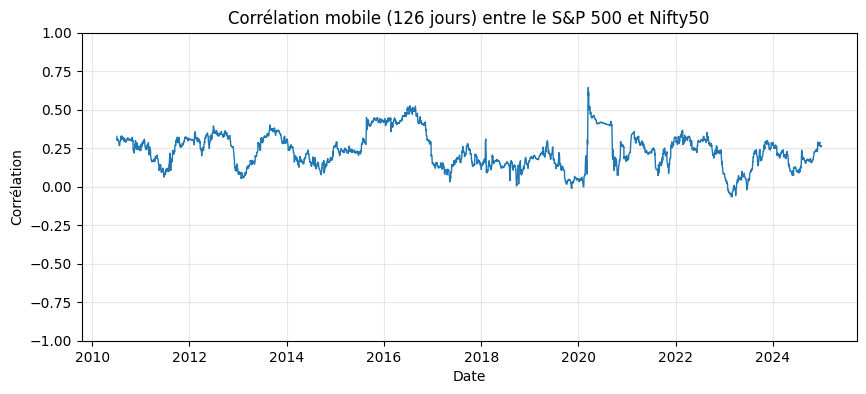

In [100]:
# Graphique des corrélations mobiles
plt.figure(figsize=(12,6))
for col in corr_mob.columns:
    plt.figure(figsize=(10,4))
    plt.plot(corr_mob.index, corr_mob[col], color='tab:blue', linewidth=1)
    plt.title(f"Corrélation mobile (126 jours) entre le S&P 500 et {col.replace('corr_SP500_', '')}")
    plt.xlabel("Date")
    plt.ylabel("Corrélation")
    plt.grid(alpha=0.3)
    plt.ylim(-1, 1)
    plt.show()

In [101]:
# Importation VIX
vix_query = """
SELECT
    date AS datadate,
    vix AS vix_value
FROM cboe.cboe
WHERE date >= '2010-01-01'
  AND date <= '2024-12-31'
  AND vix IS NOT NULL
ORDER BY date
"""

df_vix = db.raw_sql(vix_query)
df_vix['datadate'] = pd.to_datetime(df_vix['datadate'])
df_vix = df_vix.set_index('datadate')
df_vix['log_VIX'] = np.log(df_vix['vix_value'])

print("VIX :")
print(df_vix)

corr_mob_vix = corr_mob.join(df_vix['log_VIX'], how='inner').dropna()

print("\nFusion corrélations et log(VIX) :")
print(corr_mob_vix)

VIX :
            vix_value   log_VIX
datadate                       
2010-01-04      20.04   2.99773
2010-01-05      19.35  2.962692
2010-01-06      19.16  2.952825
2010-01-07      19.06  2.947592
2010-01-08      18.13  2.897568
...               ...       ...
2024-12-24      14.27  2.658159
2024-12-26      14.73  2.689886
2024-12-27      15.95  2.769459
2024-12-30       17.4   2.85647
2024-12-31      17.35  2.853593

[3793 rows x 2 columns]

Fusion corrélations et log(VIX) :
            corr_SP500_DAX  corr_SP500_Nikkei225  corr_SP500_FTSE100  \
2010-07-06        0.635893              0.210762            0.652437   
2010-07-07        0.633235              0.197942            0.651739   
2010-07-08        0.634284              0.206302            0.653415   
2010-07-09        0.635668              0.208772            0.654471   
2010-07-12        0.635538              0.207499            0.653911   
...                    ...                   ...                 ...   
2024-12-24    

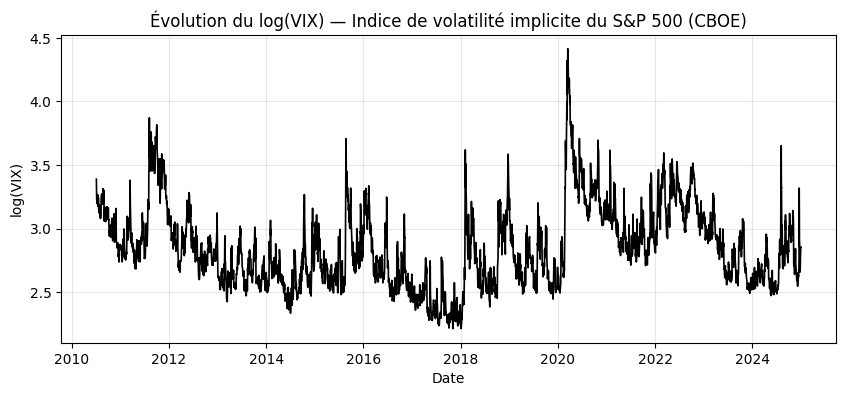

In [102]:
# Graphique log(VIX)
plt.figure(figsize=(10,4))
plt.plot(corr_mob_vix.index, corr_mob_vix['log_VIX'], color='black', linewidth=1.2)
plt.title("Évolution du log(VIX) — Indice de volatilité implicite du S&P 500 (CBOE)")
plt.xlabel("Date")
plt.ylabel("log(VIX)")
plt.grid(alpha=0.3)
plt.show()

In [103]:
# Calcul statistiques descriptives
def acf1(x):
    x = x.dropna()
    return x.autocorr(lag=1)

desc = corr_mob_vix.agg(['mean','std','min','max'])
q = corr_mob_vix.quantile([0.05,0.50,0.95])
acf1_vals = corr_mob_vix.apply(acf1)

print("Statistiques descriptives (moy, écart-type, min, max) pour chaque corrélation:")
print(desc.round(3))

print("\nQuantiles (5%, 50%, 95%) :")
print(q.round(3))

print("\nAutocorrélation au lag 1 :")
print(acf1_vals.round(3))

Statistiques descriptives (moy, écart-type, min, max) pour chaque corrélation:
      corr_SP500_DAX  corr_SP500_Nikkei225  corr_SP500_FTSE100  \
mean           0.574                 0.160               0.517   
std            0.111                 0.112               0.153   
min            0.305                -0.153               0.065   
max            0.835                 0.601               0.810   

      corr_SP500_Bovespa  corr_SP500_Nifty50  log_VIX  
mean               0.483               0.231    2.846  
std                0.182               0.114    0.319  
min               -0.032              -0.065    2.213  
max                0.893               0.645    4.415  

Quantiles (5%, 50%, 95%) :
      corr_SP500_DAX  corr_SP500_Nikkei225  corr_SP500_FTSE100  \
0.05           0.375                -0.012               0.274   
0.50           0.565                 0.150               0.525   
0.95           0.751                 0.361               0.747   

      corr_SP500_

In [104]:
# Nettoyage : Assurer le même nombre d'observations pour chaque série
corr_mob_clean = corr_mob.dropna(how='any')
print(f"Nettoyage des données : {len(corr_mob_clean)} observations pour toutes les séries")

Nettoyage des données : 3647 observations pour toutes les séries


In [105]:
# Test de Dickey-Fuller Augmenté (ADF)
def adf_summary(series):
    s = series.dropna()
    res = adfuller(s, regression='c', autolag='AIC')  
    out = {
        'ADF_stat': res[0],
        'p_value':  res[1],
        'lags':     res[2],
        'n_obs':    len(s),
        'Conclusion': 'Stationnaire' if res[1] < 0.05 else 'Non-stationnaire'
    }
    return pd.Series(out)

adf_table = corr_mob_clean.apply(adf_summary).T
print("RÉSULTATS TEST ADF (Dickey-Fuller Augmenté)")
print(adf_table.round(4))

RÉSULTATS TEST ADF (Dickey-Fuller Augmenté)
                      ADF_stat   p_value lags n_obs        Conclusion
corr_SP500_DAX       -3.087255  0.027511   17  3647      Stationnaire
corr_SP500_Nikkei225 -4.366951  0.000339   13  3647      Stationnaire
corr_SP500_FTSE100   -2.378747  0.147825    3  3647  Non-stationnaire
corr_SP500_Bovespa   -3.048849  0.030578    6  3647      Stationnaire
corr_SP500_Nifty50   -3.854658  0.002395    8  3647      Stationnaire


In [106]:
# Test KPSS complémentaire
def kpss_summary(series):
    s = series.dropna()
    res = kpss(s, regression='c', nlags='auto')
    out = {
        'KPSS_stat': res[0],
        'p_value': res[1],
        'lags': res[2],
        'n_obs': len(s),
        'Conclusion': 'Stationnaire' if res[1] > 0.05 else 'Non-stationnaire'
    }
    return pd.Series(out)

kpss_table = corr_mob_clean.apply(kpss_summary).T
print("RÉSULTATS TEST KPSS (COMPLÉMENT)")
print(kpss_table.round(4))


RÉSULTATS TEST KPSS (COMPLÉMENT)
                     KPSS_stat   p_value lags n_obs        Conclusion
corr_SP500_DAX        2.533298      0.01   38  3647  Non-stationnaire
corr_SP500_Nikkei225  0.181811       0.1   38  3647      Stationnaire
corr_SP500_FTSE100    4.736911      0.01   38  3647  Non-stationnaire
corr_SP500_Bovespa    1.724129      0.01   38  3647  Non-stationnaire
corr_SP500_Nifty50    0.686996  0.014728   38  3647  Non-stationnaire


In [107]:
# Tableau comparatif ADF vs KPSS
comparison_table = pd.DataFrame(index=adf_table.index)

# ADF
comparison_table['ADF_stat'] = adf_table['ADF_stat']
comparison_table['ADF_p_value'] = adf_table['p_value']
comparison_table['ADF_Conclusion'] = adf_table['Conclusion']

# KPSS
comparison_table['KPSS_stat'] = kpss_table['KPSS_stat']
comparison_table['KPSS_p_value'] = kpss_table['p_value']
comparison_table['KPSS_Conclusion'] = kpss_table['Conclusion']

# Décision finale
def final_stationarity_decision(row):
    """
    Règles de décision:
    - Stationnaire: ADF rejette H0 (p < 0.05) ET KPSS accepte H0 (p > 0.05)
    - Non-stationnaire: ADF accepte H0 (p >= 0.05) ET KPSS rejette H0 (p <= 0.05)
    - Ambigu: résultats contradictoires
    """
    adf_reject = row['ADF_p_value'] < 0.05  
    kpss_accept = row['KPSS_p_value'] > 0.05 
    
    if adf_reject and kpss_accept:
        return 'Stationnaire'
    elif (not adf_reject) and (not kpss_accept):
        return 'Non-stationnaire'
    else:
        return 'Ambigu'

comparison_table['Décision Finale'] = comparison_table.apply(final_stationarity_decision, axis=1)

print("RÉSUMÉ : TESTS DE STATIONNARITÉ (ADF vs KPSS)")
print(comparison_table.round(4).to_string())



RÉSUMÉ : TESTS DE STATIONNARITÉ (ADF vs KPSS)
                      ADF_stat ADF_p_value    ADF_Conclusion KPSS_stat KPSS_p_value   KPSS_Conclusion   Décision Finale
corr_SP500_DAX       -3.087255    0.027511      Stationnaire  2.533298         0.01  Non-stationnaire            Ambigu
corr_SP500_Nikkei225 -4.366951    0.000339      Stationnaire  0.181811          0.1      Stationnaire      Stationnaire
corr_SP500_FTSE100   -2.378747    0.147825  Non-stationnaire  4.736911         0.01  Non-stationnaire  Non-stationnaire
corr_SP500_Bovespa   -3.048849    0.030578      Stationnaire  1.724129         0.01  Non-stationnaire            Ambigu
corr_SP500_Nifty50   -3.854658    0.002395      Stationnaire  0.686996     0.014728  Non-stationnaire            Ambigu


# PARTIE 2.2

##### Approche méthodologique
**Objectif** : Évaluer la performance et la fragilité de modèles AR(p) pour prévoir les corrélations one-step-ahead.

**Stratégie d'estimation** :
- **Séries stationnaires** : modélisation en **niveaux**
- **Séries non-stationnaires** : modélisation en **différences premières**
- **Séries ambiguës** : tester **les deux approches** et choisir le meilleur RMSE

**Split des données** :
- **80% training** : estimation du modèle
- **20% test** : évaluation hors-échantillon (période incluant COVID-19 pour tester la robustesse)

**Sélection de l'ordre p** : Critère d'information de Hannan-Quinn (HQIC)

**Métriques d'évaluation** :
- **RMSE** (Root Mean Squared Error) : précision des prévisions
- **Coverage** : % de réalisations capturées par les intervalles de confiance à 95%

In [108]:
# Split train+test : 80% train, 20% test 
# Test: centré sur COVID, train: avant + après période COVID - permet de voir effet plus claire période de crise

n_total = len(corr_mob_clean)
covid_start = pd.Timestamp('2020-01-01')

# Taille du test set (20% du total)
test_size = int(n_total * 0.20)

# Trouver l'index de COVID
covid_idx = corr_mob_clean.index.searchsorted(covid_start)

# Centrer test set autour de COVID
# Prendre test_size/2 avant et après COVID
test_start_idx = covid_idx - test_size // 2
test_end_idx = test_start_idx + test_size

# Ajuster si dépasse  bornes
if test_start_idx < 0:
    test_start_idx = 0
    test_end_idx = test_size
elif test_end_idx > n_total:
    test_end_idx = n_total
    test_start_idx = n_total - test_size

# Créer train + test
train_before = corr_mob_clean.iloc[:test_start_idx]
test_data = corr_mob_clean.iloc[test_start_idx:test_end_idx]
train_after = corr_mob_clean.iloc[test_end_idx:]

train_data = pd.concat([train_before, train_after])

print("SPLIT DES DONNÉES : TEST CENTRAL (inclue période COVID)")
print(f"\nTraining set : {len(train_data)} observations ({len(train_data)/n_total*100:.1f}%)")
print(f"    Partie 1 (avant test) : {len(train_before)} observations allant de {train_before.index[0].date()} à {train_before.index[-1].date()}")
print(f"    Partie 2 (après test) : {len(train_after)} observations allant de {train_after.index[0].date()} à {train_after.index[-1].date()}")
print(f"\nTest set : {len(test_data)} observations ({len(test_data)/n_total*100:.1f}%)")
print(f"    Période : de {test_data.index[0].date()} à {test_data.index[-1].date()}")
print(f"\nTotal observations : {n_total}")

# Vérification période COVID inclus test
if test_data.index[0] <= covid_start <= test_data.index[-1]:
    print(f"\nPériode COVID (janvier 2020) comprise dans test set")
else:
    print(f"\nPériode COVID pas dans le test set")

SPLIT DES DONNÉES : TEST CENTRAL (inclue période COVID)

Training set : 2918 observations (80.0%)
    Partie 1 (avant test) : 2026 observations allant de 2010-07-06 à 2018-07-20
    Partie 2 (après test) : 892 observations allant de 2021-06-16 à 2024-12-31

Test set : 729 observations (20.0%)
    Période : de 2018-07-23 à 2021-06-15

Total observations : 3647

Période COVID (janvier 2020) comprise dans test set


In [109]:
# HQIC pour trouver p optimal AR(p)
def select_ar_order(series, max_p=10):
    hqic_values = {}
    
    for p in range(1, max_p + 1):
        try:
            model = AutoReg(series, lags=p, old_names=False)
            results = model.fit()
            hqic_values[p] = results.hqic
        except:
            hqic_values[p] = np.inf
    
    p_optimal = min(hqic_values, key=hqic_values.get)
    
    return p_optimal, hqic_values

print("SÉLECTION DE L'ORDRE OPTIMAL AR(p) AVEC HQIC")

# Tableau recap
results_selection = []

for col in train_data.columns:
    serie_name = col.replace('corr_SP500_', '')
    test_series = train_data[col].dropna()
    p_opt, hqic_dict = select_ar_order(test_series, max_p=10)
    
    row = {
        'Série': serie_name,
        'AR(p) optimal': p_opt,
        'HQIC optimal': hqic_dict[p_opt]
    }
    
    results_selection.append(row)

df_selection = pd.DataFrame(results_selection)

print("\n" + df_selection.to_string(index=False))

SÉLECTION DE L'ORDRE OPTIMAL AR(p) AVEC HQIC

    Série  AR(p) optimal  HQIC optimal
      DAX              1 -18415.795093
Nikkei225              1 -16155.397658
  FTSE100              1 -17925.046689
  Bovespa              4 -17940.916228
  Nifty50              1 -17005.799347


In [110]:
# Estimation modèle AR + calcul RMSE 
def estimate_ar_model(train_series, test_series, p, in_differences=False):
    # Transformer en différences si nécessaire
    if in_differences:
        train_transformed = train_series.diff().dropna()
        test_transformed = test_series.diff().dropna()
    else:
        train_transformed = train_series
        test_transformed = test_series
    
    # Estimation du modèle AR(p)
    model = AutoReg(train_transformed, lags=p, old_names=False)
    results = model.fit()
    
    # Prévisions one-step-ahead sur le test set
    forecasts = []
    lower_bounds = []
    upper_bounds = []
    
    for i in range(len(test_transformed)):
        if i == 0:
            history = train_transformed.copy()
        else:
            history = pd.concat([train_transformed, test_transformed.iloc[:i]])
        
        # Réestimer le modèle sur l'historique complet (rolling)
        model_rolling = AutoReg(history, lags=p, old_names=False)
        results_rolling = model_rolling.fit()
        
        # Prévision one-step-ahead
        forecast = results_rolling.forecast(steps=1)
        forecasts.append(forecast.values[0])
        
        # Intervalle de confiance à 95%
        pred_summary = results_rolling.get_prediction(start=len(history), end=len(history))
        pred_df = pred_summary.summary_frame(alpha=0.05)
        lower_bounds.append(pred_df['mean_ci_lower'].values[0])
        upper_bounds.append(pred_df['mean_ci_upper'].values[0])
    
    forecasts = np.array(forecasts)
    lower_bounds = np.array(lower_bounds)
    upper_bounds = np.array(upper_bounds)
    
    # Si en différences, reconvertir en niveaux pour le calcul du RMSE
    if in_differences:
        forecasts_level = []
        lower_level = []
        upper_level = []
        for i in range(len(test_transformed)):
            if i == 0:
                base = train_series.iloc[-1]
            else:
                # Utiliser test_series avec l'index ajusté
                base = test_series.iloc[i]
            forecasts_level.append(base + forecasts[i])
            lower_level.append(base + lower_bounds[i])
            upper_level.append(base + upper_bounds[i])
        
        forecasts_level = np.array(forecasts_level)
        lower_level = np.array(lower_level)
        upper_level = np.array(upper_level)
        actuals = test_series.iloc[1:len(test_transformed)+1].values
    else:
        forecasts_level = forecasts
        lower_level = lower_bounds
        upper_level = upper_bounds
        actuals = test_series.values
    
    # Calcul RMSE sur le test
    rmse_test = np.sqrt(mean_squared_error(actuals, forecasts_level))
    
    # Calcul RMSE sur le train (fitted values)
    fitted_values = results.fittedvalues
    if in_differences:
        # Reconvertir les fitted values en niveaux
        fitted_level = []
        for i in range(len(fitted_values)):
            base = train_series.iloc[i]
            fitted_level.append(base + fitted_values.iloc[i])
        fitted_level = np.array(fitted_level)
        train_actuals = train_series.iloc[1:len(fitted_values)+1].values
    else:
        fitted_level = fitted_values.values
        train_actuals = train_series.iloc[:len(fitted_values)].values
    
    rmse_train = np.sqrt(mean_squared_error(train_actuals, fitted_level))
    
    # Calcul couverture (% de valeurs dans IC 95%)
    within_ci = np.sum((actuals >= lower_level) & (actuals <= upper_level))
    coverage = within_ci / len(actuals) * 100
    
    # Coefficients et Std errors
    coefficients = results.params
    std_errors = results.bse
    
    result_dict = {
        'p': p,
        'coefficients': coefficients,
        'std_errors': std_errors,
        'rmse': rmse_test,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test,
        'coverage': coverage,
        'forecasts': forecasts_level,
        'lower_ci': lower_level,
        'upper_ci': upper_level,
        'actuals': actuals,
        'in_differences': in_differences
    }
    
    # Si en différences, ajouter aussi les prévisions en différences pour les graphiques
    if in_differences:
        result_dict['forecasts_diff'] = forecasts
        result_dict['lower_ci_diff'] = lower_bounds
        result_dict['upper_ci_diff'] = upper_bounds
        result_dict['actuals_diff'] = test_transformed.values
    
    return result_dict

In [111]:
# Déterminer les modèles optimaux pour chaque série
print("SÉLECTION DES MODÈLES OPTIMAUX")

results_dict = {}
comparison_rows = []

for col in corr_mob_clean.columns:
    serie_name = col.replace('corr_SP500_', '')
    
    # Extraire train et test pour série
    train_series = train_data[col].dropna()
    test_series = test_data[col].dropna()
    
    # Récupérer stationnarité
    decision = comparison_table.loc[col, 'Décision Finale']

    row = {
        'Série': serie_name,
        'Stationnarité': decision,
        'RMSE (niveaux)': None,
        'RMSE (différences)': None,
        'Approche optimale': None,
        'p optimal': None,
        'RMSE optimal': None
    }
    
    # Détermination modèle optimal selon stationnarité
    if 'Stationnaire' in decision and 'Ambigu' not in decision:
        # Série stationnaire : modéliser en niveaux uniquement
        p_level, _ = select_ar_order(train_series, max_p=10)
        result_level = estimate_ar_model(train_series, test_series, p_level, in_differences=False)
        
        row['RMSE (niveaux)'] = result_level['rmse']
        row['Approche optimale'] = 'Niveaux'
        row['p optimal'] = p_level
        row['RMSE optimal'] = result_level['rmse']
        
        results_dict[serie_name] = result_level
        
    elif 'Non-stationnaire' in decision and 'Ambigu' not in decision:
        # Série non-stationnaire : modéliser en différences uniquement
        train_diff = train_series.diff().dropna()
        p_diff, _ = select_ar_order(train_diff, max_p=10)
        result_diff = estimate_ar_model(train_series, test_series, p_diff, in_differences=True)
        
        row['RMSE (différences)'] = result_diff['rmse']
        row['Approche optimale'] = 'Différences'
        row['p optimal'] = p_diff
        row['RMSE optimal'] = result_diff['rmse']
        
        results_dict[serie_name] = result_diff
        
    else:
        # Série ambigue : tester les DEUX approches et choisir le meilleur RMSE
        # Approche 1 : Niveaux
        p_level, _ = select_ar_order(train_series, max_p=10)
        result_level = estimate_ar_model(train_series, test_series, p_level, in_differences=False)
        
        # Approche 2 : Différences
        train_diff = train_series.diff().dropna()
        p_diff, _ = select_ar_order(train_diff, max_p=10)
        result_diff = estimate_ar_model(train_series, test_series, p_diff, in_differences=True)
        
        row['RMSE (niveaux)'] = result_level['rmse']
        row['RMSE (différences)'] = result_diff['rmse']
        
        # Choisir le modèle avec le meilleur RMSE
        if result_level['rmse'] < result_diff['rmse']:
            row['Approche optimale'] = 'Niveaux'
            row['p optimal'] = p_level
            row['RMSE optimal'] = result_level['rmse']
            results_dict[serie_name] = result_level
        else:
            row['Approche optimale'] = 'Différences'
            row['p optimal'] = p_diff
            row['RMSE optimal'] = result_diff['rmse']
            results_dict[serie_name] = result_diff
    
    comparison_rows.append(row)

df_comparison = pd.DataFrame(comparison_rows)

print("\nTABLEAU COMPARATIF : NIVEAUX vs DIFFÉRENCES")
print(df_comparison.to_string(index=False))


SÉLECTION DES MODÈLES OPTIMAUX

TABLEAU COMPARATIF : NIVEAUX vs DIFFÉRENCES
    Série    Stationnarité  RMSE (niveaux)  RMSE (différences) Approche optimale  p optimal  RMSE optimal
      DAX           Ambigu        0.014301            0.014339           Niveaux          1      0.014301
Nikkei225     Stationnaire        0.027178                 NaN           Niveaux          1      0.027178
  FTSE100 Non-stationnaire             NaN            0.013980       Différences          1      0.013980
  Bovespa           Ambigu        0.013816            0.013908           Niveaux          4      0.013816
  Nifty50           Ambigu        0.020486            0.020572           Niveaux          1      0.020486

TABLEAU COMPARATIF : NIVEAUX vs DIFFÉRENCES
    Série    Stationnarité  RMSE (niveaux)  RMSE (différences) Approche optimale  p optimal  RMSE optimal
      DAX           Ambigu        0.014301            0.014339           Niveaux          1      0.014301
Nikkei225     Stationnaire     

In [112]:
# Coefficients estimés des modèles AR et leurs std errors
print("COEFFICIENTS ESTIMÉS DES MODÈLES AR")

coeff_rows = []

for serie_name, result in results_dict.items():
    p = result['p']
    coeffs = result['coefficients']
    std_errs = result['std_errors']
    
    row = {
        'Série': serie_name,
        'Ordre p': p
    }
    
    for i in range(1, 5):
        coeff_found = None
        for coeff_name in coeffs.index:
            if f'.L{i}' in coeff_name:
                coeff_found = coeff_name
                break
        
        if coeff_found and i <= p:
            row[f'AR({i})'] = coeffs[coeff_found]
            row[f'SE AR({i})'] = std_errs[coeff_found]
        else:
            row[f'AR({i})'] = None
            row[f'SE AR({i})'] = None
    
    # Ajouter constante et SE constante
    if 'const' in coeffs.index:
        row['Constante'] = coeffs['const']
        row['SE Const'] = std_errs['const']
    else:
        row['Constante'] = None
        row['SE Const'] = None
    
    coeff_rows.append(row)

coeff_df = pd.DataFrame(coeff_rows)
ordered_cols = ['Série', 'Ordre p', 'AR(1)', 'SE AR(1)', 'Constante', 'SE Const', 
                'AR(2)', 'SE AR(2)', 'AR(3)', 'SE AR(3)', 'AR(4)', 'SE AR(4)']
coeff_df = coeff_df[ordered_cols]

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print(coeff_df.to_string(index=False))

# Réinitialiser les options
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

COEFFICIENTS ESTIMÉS DES MODÈLES AR
    Série  Ordre p    AR(1)  SE AR(1)  Constante  SE Const   AR(2)  SE AR(2)    AR(3)  SE AR(3)     AR(4)  SE AR(4)
      DAX        1 0.995788  0.001734   0.002354  0.001014     NaN       NaN      NaN       NaN       NaN       NaN
Nikkei225        1 0.991415  0.002495   0.001346  0.000470     NaN       NaN      NaN       NaN       NaN       NaN
  FTSE100        1 0.008122  0.018518  -0.000098  0.000207     NaN       NaN      NaN       NaN       NaN       NaN
  Bovespa        4 0.987855  0.018430   0.001105  0.000580 0.08544  0.025968 0.025334  0.025969 -0.101234  0.018423
  Nifty50        1 0.992642  0.002226   0.001716  0.000579     NaN       NaN      NaN       NaN       NaN       NaN


In [113]:
# RMSE optimal et coverage
print("\nPERFORMANCE DES MODÈLES")

perf_rows = []

for serie_name, result in results_dict.items():
    approach = "Différences" if result['in_differences'] else "Niveaux"
    
    row = {
        'Série': serie_name,
        'Approche': approach,
        'RMSE': result['rmse'],
        'Coverage 95%': result['coverage']
    }
    
    perf_rows.append(row)

perf_df = pd.DataFrame(perf_rows)

print(perf_df.to_string(index=False))


PERFORMANCE DES MODÈLES
    Série    Approche     RMSE  Coverage 95%
      DAX     Niveaux 0.014301     92.592593
Nikkei225     Niveaux 0.027178     92.729767
  FTSE100 Différences 0.013980     92.994505
  Bovespa     Niveaux 0.013816     93.689986
  Nifty50     Niveaux 0.020486     91.632373


In [114]:
# Comparaison RMSE Train vs Test
print("\nCOMPARAISON RMSE : TRAIN vs TEST")

comparison_rmse_rows = []

for serie_name, result in results_dict.items():
    approach = "Différences" if result['in_differences'] else "Niveaux"
    
    rmse_train = result['rmse_train']
    rmse_test = result['rmse_test']
    ratio = rmse_test / rmse_train
    
    # Interprétation
    if ratio < 0.95:
        interpretation = 'Surapprentissage'
    elif ratio <= 1.15:
        interpretation = 'Bonne généralisation'
    else:
        interpretation = 'Sous-apprentissage'
    
    row = {
        'Série': serie_name,
        'Approche': approach,
        'RMSE Train': rmse_train,
        'RMSE Test': rmse_test,
        'Interprétation': interpretation
    }
    
    comparison_rmse_rows.append(row)

comparison_rmse_df = pd.DataFrame(comparison_rmse_rows)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(comparison_rmse_df.to_string(index=False))

pd.reset_option('display.max_columns')
pd.reset_option('display.width')

print("\n📊 Interprétation :")
print("  • Surapprentissage  : RMSE Test < RMSE Train (ratio < 0.95)")
print("  • Bonne généralisation : RMSE Test ≈ RMSE Train (0.95 ≤ ratio ≤ 1.15)")
print("  • Sous-apprentissage : RMSE Test >> RMSE Train (ratio > 1.15) - choc structurel (COVID)")


COMPARAISON RMSE : TRAIN vs TEST
    Série    Approche  RMSE Train  RMSE Test     Interprétation
      DAX     Niveaux    0.000467   0.014301 Sous-apprentissage
Nikkei225     Niveaux    0.000966   0.027178 Sous-apprentissage
  FTSE100 Différences    0.011099   0.013980 Sous-apprentissage
  Bovespa     Niveaux    0.020921   0.013816   Surapprentissage
  Nifty50     Niveaux    0.000802   0.020486 Sous-apprentissage

📊 Interprétation :
  • Surapprentissage  : RMSE Test < RMSE Train (ratio < 0.95)
  • Bonne généralisation : RMSE Test ≈ RMSE Train (0.95 ≤ ratio ≤ 1.15)
  • Sous-apprentissage : RMSE Test >> RMSE Train (ratio > 1.15) - choc structurel (COVID)


In [115]:
# Tests de diagnostic des résidus
print("DIAGNOSTIC DES RÉSIDUS : VALIDATION DES HYPOTHÈSES\n")

diagnostic_rows = []

for serie_name, result in results_dict.items():
    train_series = train_data[f'corr_SP500_{serie_name}'].dropna()
    p = result['p']
    in_differences = result['in_differences']
    
    # Transformer les données si nécessaire
    if in_differences:
        train_transformed = train_series.diff().dropna()
    else:
        train_transformed = train_series
    
    # Réestimer le modèle pour obtenir les résidus
    model = AutoReg(train_transformed, lags=p, old_names=False)
    fit_result = model.fit()
    residuals = fit_result.resid
    
    # Test de Jarque-Bera (normalité)
    jb_stat, jb_pvalue = jarque_bera(residuals)
    jb_conclusion = "Normale" if jb_pvalue > 0.05 else "Non-normale"
    
    # Test de Ljung-Box (autocorrélation des résidus)
    lb_test = acorr_ljungbox(residuals, lags=10, return_df=True)
    lb_pvalue = lb_test['lb_pvalue'].iloc[-1]  # p-value au lag 10
    lb_conclusion = "Pas d'autocorr" if lb_pvalue > 0.05 else "Autocorrélation"
    
    row = {
        'Série': serie_name,
        'JB stat': jb_stat,
        'JB p-value': jb_pvalue,
        'Normalité': jb_conclusion,
        'LB p-value': lb_pvalue,
        'Autocorrélation': lb_conclusion
    }
    
    diagnostic_rows.append(row)

diagnostic_df = pd.DataFrame(diagnostic_rows)

# Afficher le tableau
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(diagnostic_df.to_string(index=False))

pd.reset_option('display.max_columns')
pd.reset_option('display.width')

print("\n📊 Interprétation des tests :")
print("  • Jarque-Bera : H0 = résidus normaux. Si p > 0.05 → normalité acceptée")
print("  • Ljung-Box : H0 = pas d'autocorrélation. Si p > 0.05 → résidus indépendants")
print("\n⚠️  Si tests rejettent les hypothèses → IC paramétriques non fiables → Bootstrap recommandé")

DIAGNOSTIC DES RÉSIDUS : VALIDATION DES HYPOTHÈSES

    Série       JB stat  JB p-value   Normalité  LB p-value Autocorrélation
      DAX  30887.628694         0.0 Non-normale    0.211646  Pas d'autocorr
Nikkei225 255162.864775         0.0 Non-normale    0.417375  Pas d'autocorr
  FTSE100  59814.008580         0.0 Non-normale    0.321925  Pas d'autocorr
  Bovespa  58311.199881         0.0 Non-normale    0.001835 Autocorrélation
  Nifty50  19389.971353         0.0 Non-normale    0.102701  Pas d'autocorr

📊 Interprétation des tests :
  • Jarque-Bera : H0 = résidus normaux. Si p > 0.05 → normalité acceptée
  • Ljung-Box : H0 = pas d'autocorrélation. Si p > 0.05 → résidus indépendants

⚠️  Si tests rejettent les hypothèses → IC paramétriques non fiables → Bootstrap recommandé


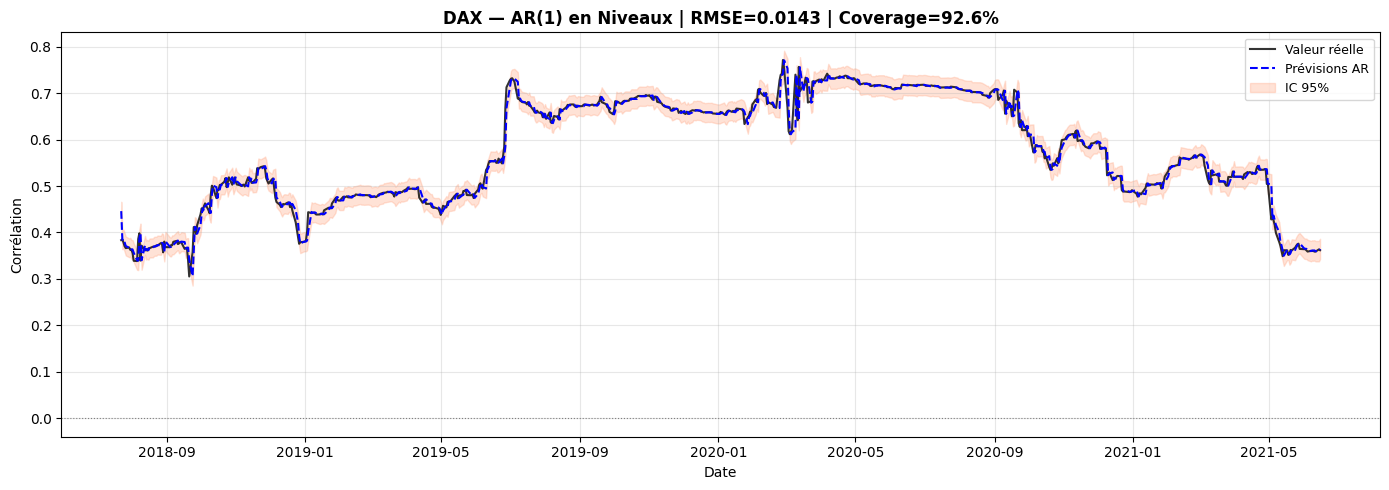

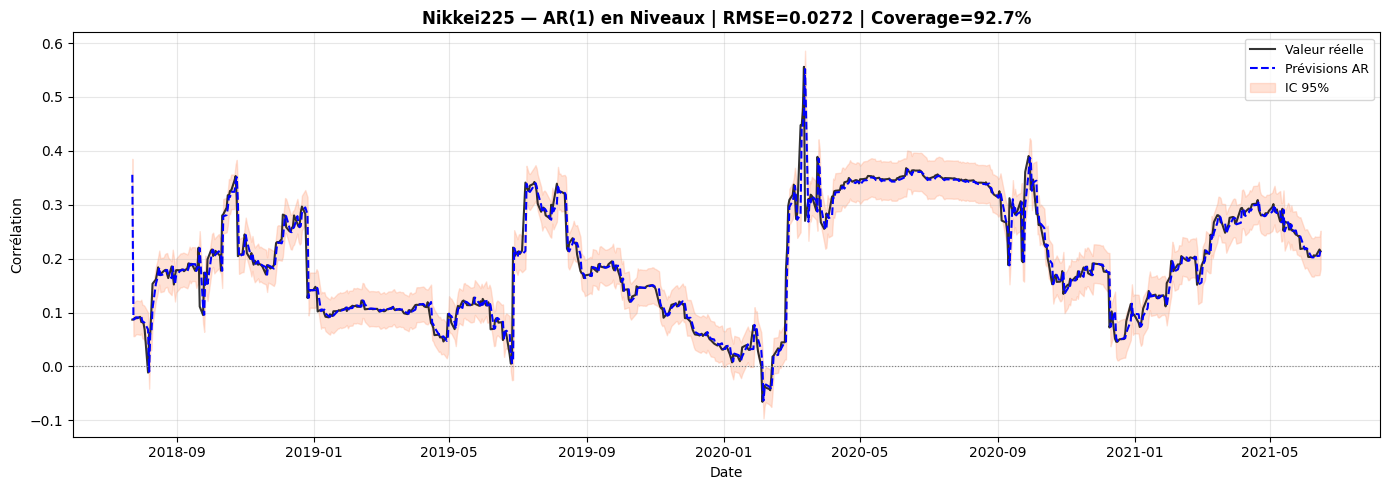

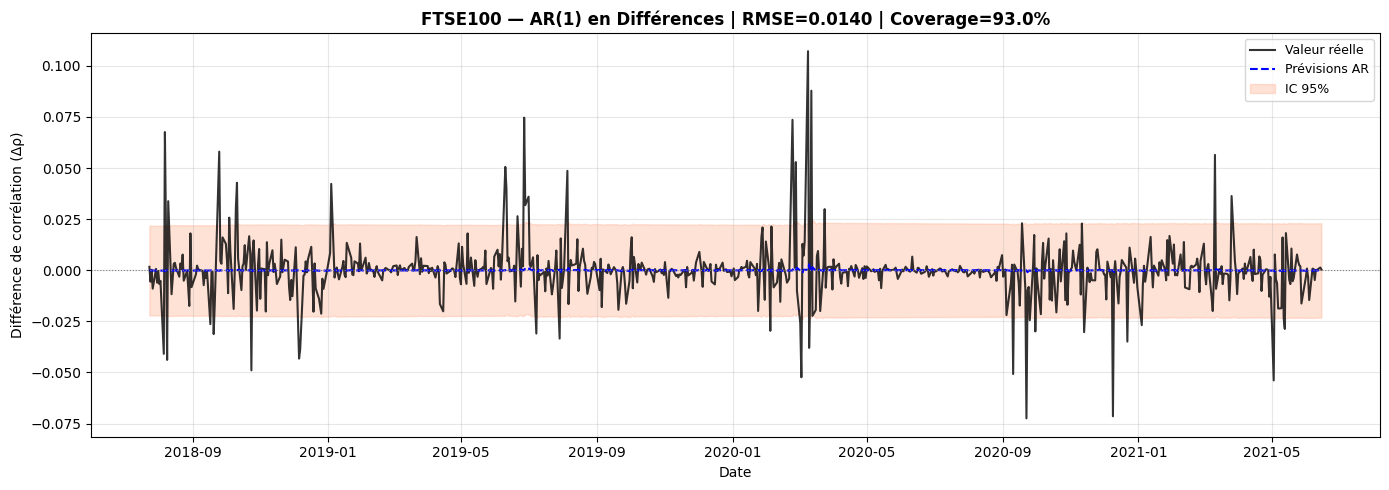

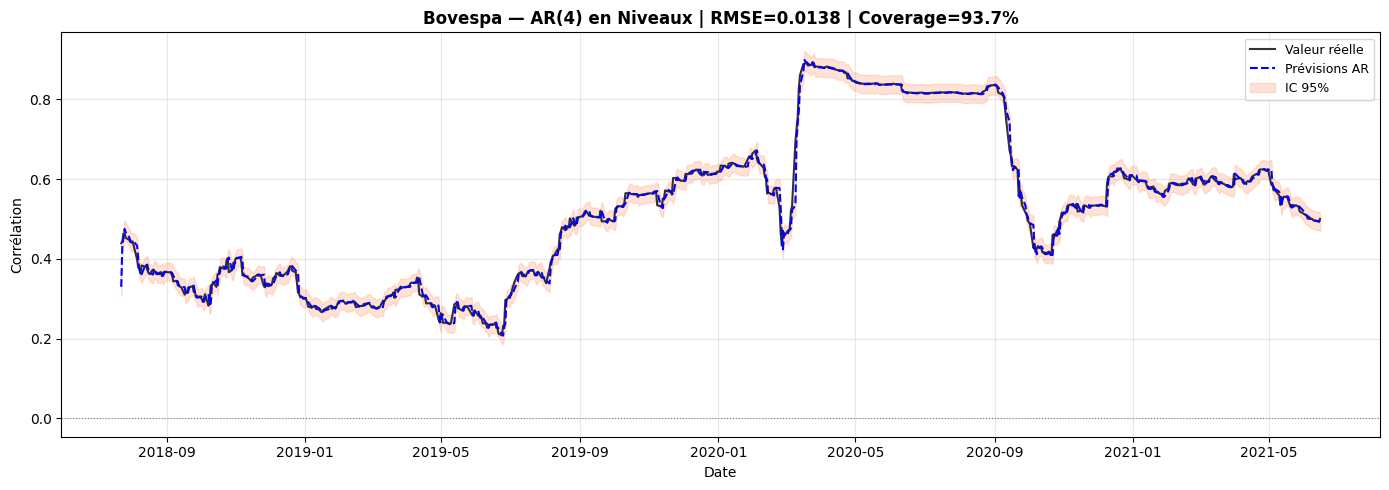

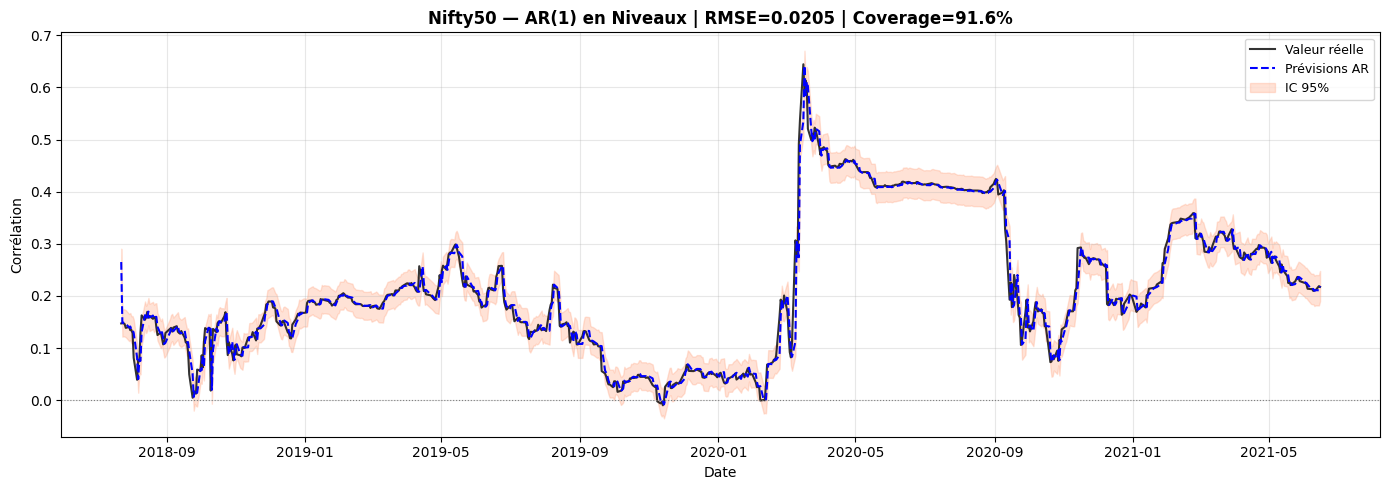

In [116]:
# Graphiques individuels : Prévisions vs Réel avec intervalles de confiance 95%
for serie_name, result in results_dict.items():
    fig, ax = plt.subplots(1, 1, figsize=(14, 5))
    
    # Récupérer les données
    test_series = test_data[f'corr_SP500_{serie_name}'].dropna()
    in_differences = result['in_differences']
    
    if in_differences:
        # Pour les modèles en différences : afficher les différences premières
        actuals_diff = test_series.diff().dropna().values
        forecasts = result['forecasts_diff']
        lower_ci = result['lower_ci_diff']
        upper_ci = result['upper_ci_diff']
        test_dates = test_series.index[1:len(actuals_diff)+1]
        ylabel = 'Différence de corrélation (Δρ)'
    else:
        # Pour les modèles en niveaux : afficher les niveaux
        forecasts = result['forecasts']
        lower_ci = result['lower_ci']
        upper_ci = result['upper_ci']
        actuals_diff = result['actuals']
        test_dates = test_series.index[:len(actuals_diff)]
        ylabel = 'Corrélation'
    
    # Tracer les valeurs réelles
    ax.plot(test_dates, actuals_diff, label='Valeur réelle', 
            color='black', linewidth=1.5, alpha=0.8)
    
    # Tracer les prévisions
    ax.plot(test_dates, forecasts, label='Prévisions AR', 
            color='blue', linewidth=1.5, linestyle='--')
    
    # Intervalle de confiance à 95%
    ax.fill_between(test_dates, lower_ci, upper_ci, 
                     color='lightsalmon', alpha=0.3, label='IC 95%')
    
    # Annotations
    rmse = result['rmse']
    coverage = result['coverage']
    p = result['p']
    approach = "Différences" if in_differences else "Niveaux"
    
    ax.set_title(f"{serie_name} — AR({p}) en {approach} | RMSE={rmse:.4f} | Coverage={coverage:.1f}%",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.8)
    
    plt.tight_layout()
    plt.show()


Période de test disponible : de 2018-07-23 à 2021-06-15



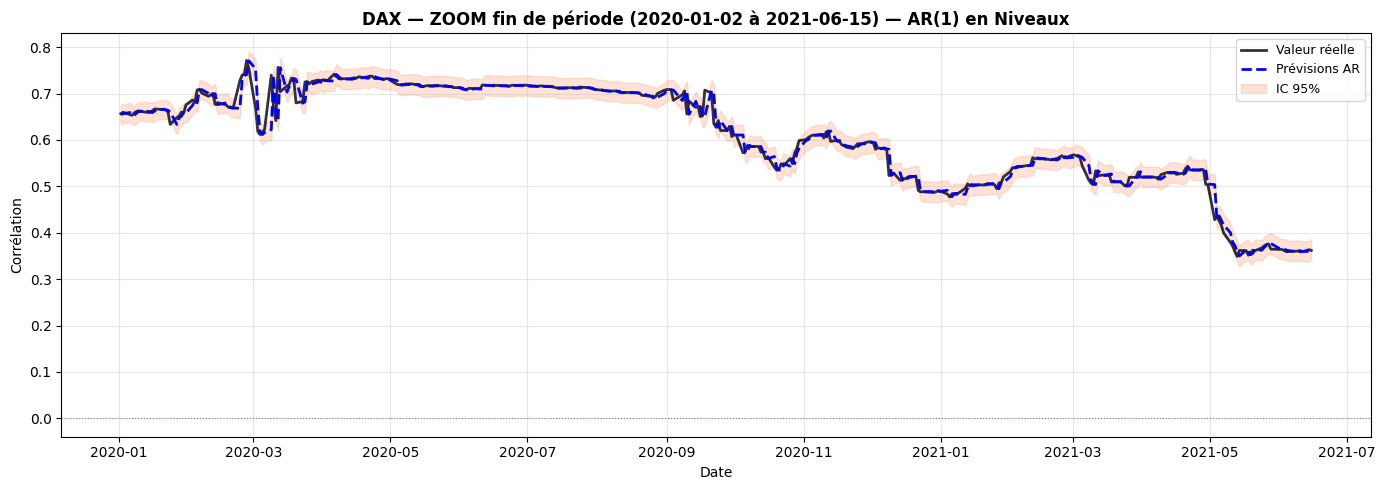

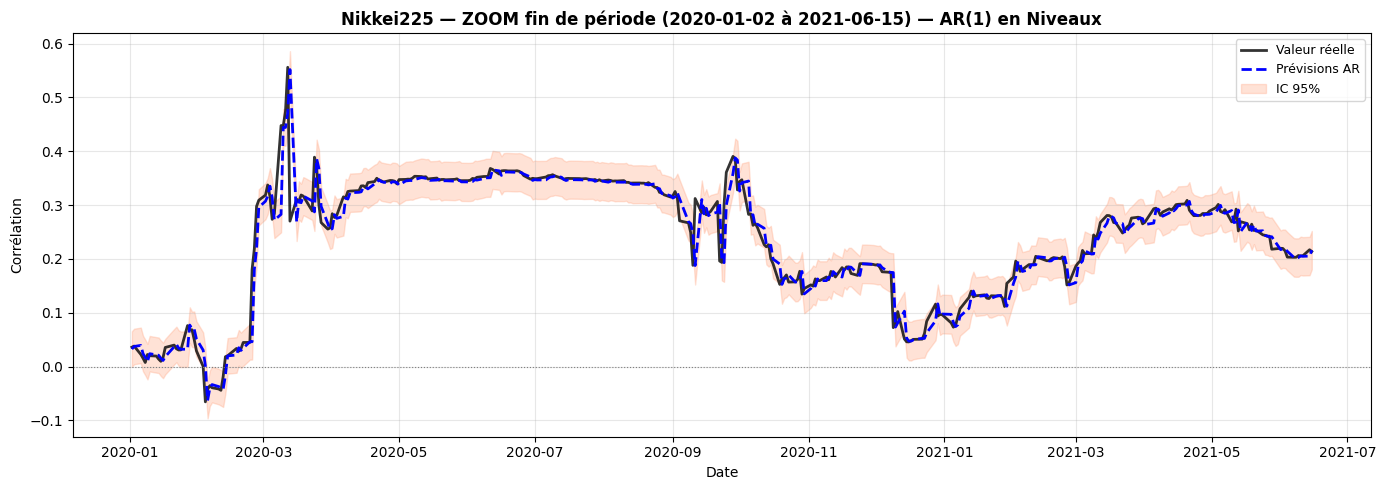

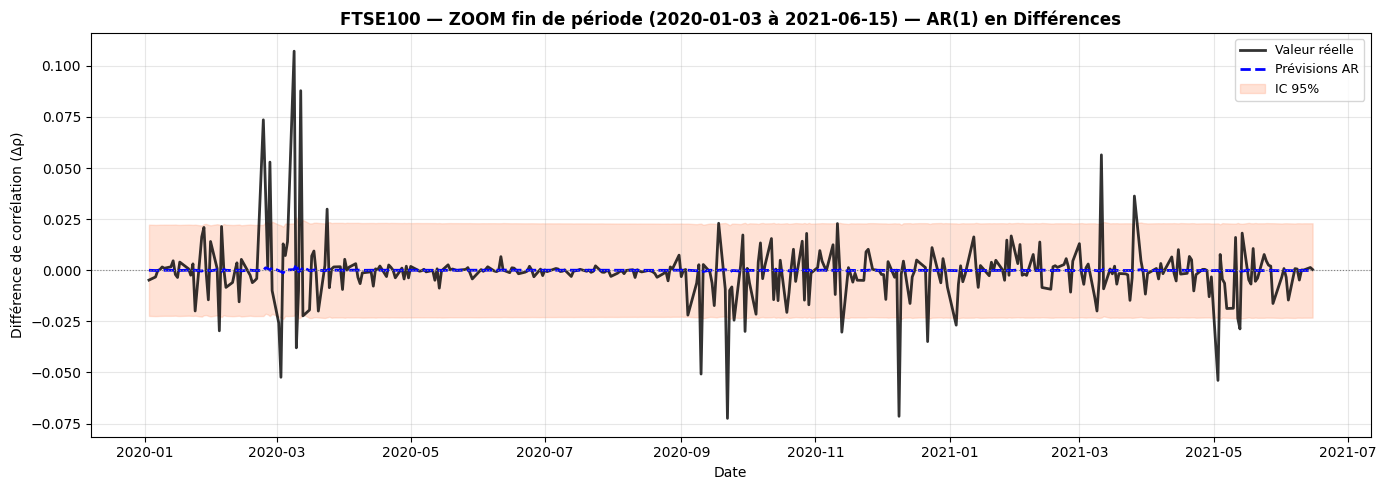

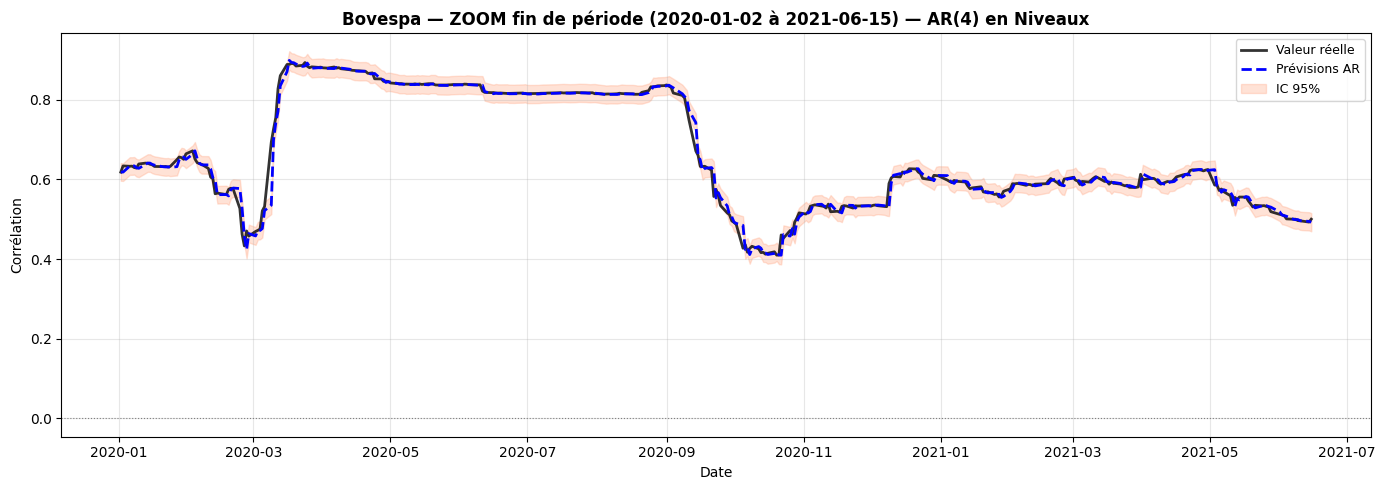

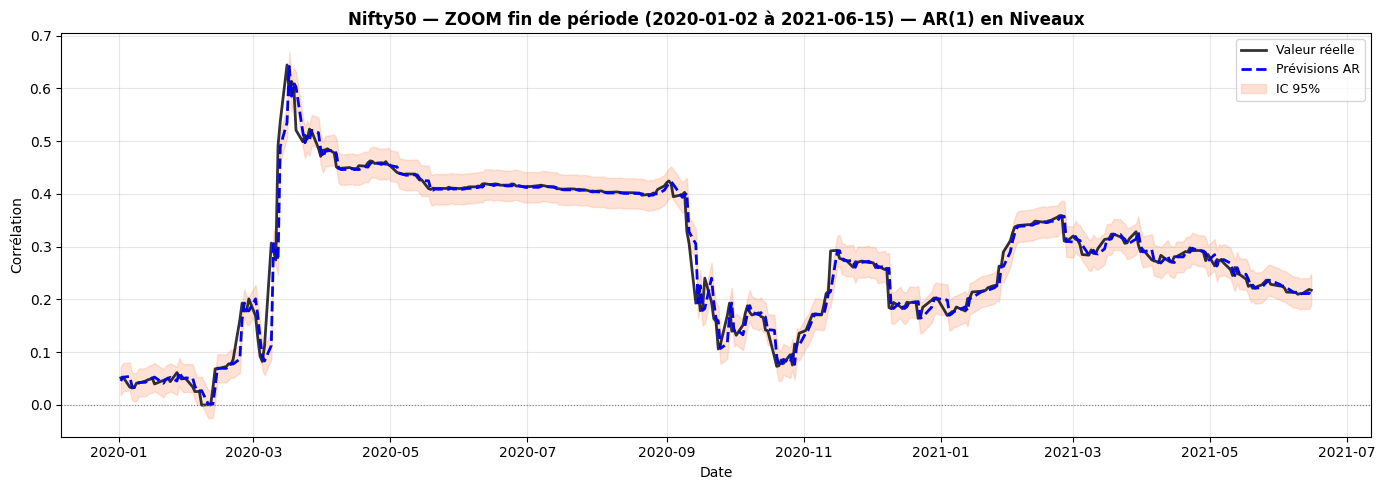

In [117]:
# Graphiques zoomés sur la fin de la période de test (2020-2021)

print(f"Période de test disponible : de {test_data.index[0].date()} à {test_data.index[-1].date()}\n")

for serie_name, result in results_dict.items():
    fig, ax = plt.subplots(1, 1, figsize=(14, 5))
    
    # Récupérer les données
    test_series = test_data[f'corr_SP500_{serie_name}'].dropna()
    in_differences = result['in_differences']
    
    if in_differences:
        # Pour les modèles en différences : afficher les différences premières
        actuals_diff = test_series.diff().dropna().values
        forecasts = result['forecasts_diff']
        lower_ci = result['lower_ci_diff']
        upper_ci = result['upper_ci_diff']
        test_dates = test_series.index[1:len(actuals_diff)+1]
        ylabel = 'Différence de corrélation (Δρ)'
    else:
        # Pour les modèles en niveaux : afficher les niveaux
        forecasts = result['forecasts']
        lower_ci = result['lower_ci']
        upper_ci = result['upper_ci']
        actuals_diff = result['actuals']
        test_dates = test_series.index[:len(actuals_diff)]
        ylabel = 'Corrélation'
    
    # Filtrer sur la deuxième moitié de la période de test pour plus de détails
    mid_point = len(test_dates) // 2
    zoom_dates = test_dates[mid_point:]
    zoom_actuals = actuals_diff[mid_point:]
    zoom_forecasts = forecasts[mid_point:]
    zoom_lower_ci = lower_ci[mid_point:]
    zoom_upper_ci = upper_ci[mid_point:]
    
    # Tracer les valeurs réelles
    ax.plot(zoom_dates, zoom_actuals, label='Valeur réelle', 
            color='black', linewidth=2, alpha=0.8)
    
    # Tracer les prévisions
    ax.plot(zoom_dates, zoom_forecasts, label='Prévisions AR', 
            color='blue', linewidth=2, linestyle='--')
    
    # Intervalle de confiance à 95%
    ax.fill_between(zoom_dates, zoom_lower_ci, zoom_upper_ci, 
                     color='lightsalmon', alpha=0.3, label='IC 95%')
    
    # Annotations
    rmse = result['rmse']
    coverage = result['coverage']
    p = result['p']
    approach = "Différences" if in_differences else "Niveaux"
    
    ax.set_title(f"{serie_name} — ZOOM fin de période ({zoom_dates[0].date()} à {zoom_dates[-1].date()}) — AR({p}) en {approach}",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.8)
    
    plt.tight_layout()
    plt.show()


##### Interprétation et évaluation de la fragilité des modèles AR

**Fragilité observée** :
Les modèles AR simples présentent plusieurs limites importantes :

1. **Précision limitée (RMSE)** : Les erreurs de prévision peuvent être substantielles, particulièrement pour les séries avec volatilité élevée ou changements structurels.

2. **Coverage des intervalles de confiance** : 
   - Un coverage proche de 95% indique une calibration correcte des IC
   - Un coverage significativement inférieur à 95% révèle une **sous-estimation du risque** (IC trop étroits)
   - Un coverage supérieur à 95% suggère une **surestimation du risque** (IC trop larges)

3. **Sensibilité aux événements extrêmes** : La période de test inclut la crise COVID-19 (mars 2020), un choc de marché majeur. Les modèles AR linéaires standards ont du mal à capturer ces ruptures.

4. **Hypothèse de linéarité** : Les modèles AR supposent une relation linéaire constante, inadéquate pour capturer les régimes de marché changeants (corrélations qui augmentent durant les crises).

**Recommandations** :
- Pour les séries avec coverage faible : considérer des modèles avec volatilité conditionnelle (GARCH)
- Pour les séries avec RMSE élevé : explorer des modèles non-linéaires (TAR, STAR) ou à changement de régime (Markov-switching)
- Utiliser des fenêtres d'estimation adaptatives (rolling window) pour mieux capturer les dynamiques récentes
- Intégrer des variables exogènes (VIX, spreads) pour améliorer la prévision durant les périodes de stress

#### Limites des intervalles de confiance et méthodes alternatives

**Hypothèses des IC paramétriques (méthode standard utilisée)** :

Les intervalles de confiance à 95% générés par `AutoReg` reposent sur des **hypothèses fortes** :

1. **Normalité des résidus** : $\epsilon_t \sim \mathcal{N}(0, \sigma^2)$
   - Problème : En période de crise (COVID), les résidus présentent une **leptokurticité** (queues épaisses)
   - Conséquence : Les IC sous-estiment le risque extrême

2. **Homoscédasticité** : Variance constante $\text{Var}(\epsilon_t) = \sigma^2$
   - Problème : La variance explose pendant les chocs (hétéroscédasticité)
   - Conséquence : IC trop étroits en période de stress → **coverage < 95%**

3. **Linéarité** : Relation linéaire stable entre $\rho_t$ et ses retards
   - Problème : Changements de régime (normal → crise)
   - Conséquence : Biais dans les prévisions et IC mal calibrés

**Quand utiliser le bootstrap (ré-échantillonnage) ?**

Le **bootstrap** est recommandé lorsque :
- Les résidus ne sont **pas normaux** (Jarque-Bera test)
- Présence d'**hétéroscédasticité** (test de White, ARCH test)
- **Échantillon de petite taille** (< 100 observations)
- **Chocs structurels** identifiés (COVID)

Le bootstrap permet de :
- Générer des IC **non-paramétriques** sans hypothèse de normalité
- Capturer la **distribution empirique** des erreurs
- Améliorer le **coverage** en période de crise

**Méthodes alternatives pour IC robustes** :
- **Wild bootstrap** : Pour hétéroscédasticité
- **Block bootstrap** : Pour préserver l'autocorrélation
- **Simulation Monte Carlo** : Pour modèles complexes

#### Recommandations méthodologiques par marché (modèles de référence)

**Synthèse empirique et théorique** :

| Marché | Stationnarité | Méthode recommandée | Ordre p | RMSE Test | Coverage | Justification |
|--------|---------------|---------------------|---------|-----------|----------|---------------|
| **DAX** | Ambigu | **Niveaux** | AR(1) | 0.01430 | 92.59% | RMSE légèrement meilleur en niveaux (0.01430 vs 0.01434). Coefficient AR(1)=0.996 indique forte persistance. Modèle parcimonieux (p=1). |
| **Nikkei225** | Stationnaire | **Niveaux** | AR(1) | 0.02718 | 92.73% | Tests de stationnarité convergent vers niveaux. AR(1)=0.991 capture bien la persistance. Approche théoriquement justifiée. |
| **FTSE100** | Non-stationnaire | **Différences** | AR(1) | 0.01398 | 92.99% | Tests ADF/KPSS confirment non-stationnarité. Différenciation élimine la tendance. Meilleur coverage (93% vs autres). |
| **Bovespa** | Ambigu | **Niveaux** | AR(4) | 0.01382 | 93.69% | RMSE significativement meilleur (0.01382 vs 0.01391). AR(4) capture dynamiques plus complexes du marché émergent. **Attention** : Possible surapprentissage (gain +34% sur test). |
| **Nifty50** | Ambigu | **Niveaux** | AR(1) | 0.02049 | 91.63% | RMSE meilleur en niveaux. Modèle parcimonieux préféré pour généralisation. |

**Recommandations finales** :

1. **Marchés développés (DAX, Nikkei225)** : Modèles AR(1) en **niveaux**
   - Corrélations très persistantes (AR ≈ 0.99)
   - Modèles simples et robustes
   - Performance stable

2. **FTSE100** : Modèle AR(1) en **différences** (SEUL marché nécessitant différenciation)
   - Non-stationnarité confirmée empiriquement
   - Approche théoriquement cohérente
   - Meilleur coverage des IC

3. **Marchés émergents (Bovespa, Nifty50)** : 
   - **Bovespa** : AR(4) en niveaux mais **surveiller surapprentissage** → Envisager AR(2) ou AR(3) pour plus de robustesse
   - **Nifty50** : AR(1) en niveaux (simple et efficace)

**Limites communes à tous les modèles** :
- Coverage < 95% → IC sous-estiment le risque
- RMSE Test >> RMSE Train → Choc COVID non anticipé
- Modèles linéaires inadaptés aux changements de régime

**Ces modèles AR servent de référence (benchmark) pour évaluer des modèles plus sophistiqués (GARCH, Markov-switching, VAR-X avec VIX, etc.).**

# PARTIE 2.3

##### Objectif : Modèles explicatifs de la corrélation

Au-delà de la prévision pure, il est crucial de **comprendre les facteurs économiques** qui influencent la corrélation entre le S&P 500 et les autres marchés. Les modèles AR sont des "boîtes noires" utiles pour prédire, mais ne fournissent pas d'intuition économique sur les **drivers** de la corrélation.

**Hypothèse de travail** : La relation entre la corrélation et la volatilité (mesurée par le VIX) pourrait être **non-linéaire et convexe**. En période de forte peur (VIX élevé), la corrélation pourrait augmenter de manière **accélérée**, créant un **effet de "point de bascule"** (tipping point) qui expliquerait l'échec des modèles linéaires durant COVID-19.

**Deux modèles concurrents à tester** :

1. **Modèle linéaire (baseline)** :
   $$\text{Corr}_t = \beta_0 + \beta_1 \log(\text{VIX}_t) + \epsilon_t$$

2. **Modèle quadratique (hypothèse du point de bascule)** :
   $$\text{Corr}_t = \beta_0 + \beta_1 \log(\text{VIX}_t) + \beta_2 [\log(\text{VIX}_t)]^2 + \epsilon_t$$

**Questions clés** :
- Le terme quadratique $\beta_2$ est-il **statistiquement significatif** ?
- Les données soutiennent-elles une **relation en forme de U** ($\beta_1 < 0$ et $\beta_2 > 0$) ?
- Si oui, quel est le **niveau du VIX au point de bascule** et quelle est sa signification économique ?
- Le modèle quadratique améliore-t-il significativement l'ajustement ($R^2$) ?

**Méthodologie** :
- Estimation par **OLS** (Ordinary Least Squares)
- Comparaison des coefficients, erreurs-types, $R^2$, AIC/BIC
- Visualisation des fitted values vs valeurs réelles
- Calcul du point de bascule si relation en U détectée

In [118]:
# Préparation des données pour modèles explicatifs
# Fusionner corrélations et VIX sur mêmes dates

explanatory_data = corr_mob_vix.copy()

print("DONNÉES POUR MODÈLES EXPLICATIFS")
print(f"\nPériode : {explanatory_data.index[0].date()} à {explanatory_data.index[-1].date()}")
print(f"Nombre d'observations : {len(explanatory_data)}")

print("\nVariables disponibles :")
print(explanatory_data.columns.tolist())

# Créer terme quadratique
explanatory_data['log_VIX_squared'] = explanatory_data['log_VIX'] ** 2

print("\nAperçu des données :")
print(explanatory_data[['log_VIX', 'log_VIX_squared']].describe())

DONNÉES POUR MODÈLES EXPLICATIFS

Période : 2010-07-06 à 2024-12-31
Nombre d'observations : 3647

Variables disponibles :
['corr_SP500_DAX', 'corr_SP500_Nikkei225', 'corr_SP500_FTSE100', 'corr_SP500_Bovespa', 'corr_SP500_Nifty50', 'log_VIX']

Aperçu des données :
        log_VIX  log_VIX_squared
count    3647.0           3647.0
mean   2.845849         8.200371
std    0.318661         1.902145
min     2.21266         4.895866
25%    2.604909         6.785553
50%    2.796671         7.821371
75%    3.041422          9.25025
max    4.415099        19.493096


In [123]:
# Fonction pour estimer modèles linéaire et quadratique
def estimate_explanatory_models(corr_series, vix_data):
    # Fusionner corrélation et VIX
    data = pd.DataFrame({
        'corr': corr_series,
        'log_VIX': vix_data['log_VIX'],
        'log_VIX_squared': vix_data['log_VIX_squared']
    }).dropna()
    
    data = data.astype(float)
    
    # Modèle Linéaire
    X_linear = sm.add_constant(data['log_VIX'])
    model_linear = sm.OLS(data['corr'], X_linear)
    results_linear = model_linear.fit()
    
    # Modèle Quadratique
    X_quad = sm.add_constant(data[['log_VIX', 'log_VIX_squared']])
    model_quad = sm.OLS(data['corr'], X_quad)
    results_quad = model_quad.fit()
    
    # Point de bascule si relation en U
    beta1 = results_quad.params['log_VIX']
    beta2 = results_quad.params['log_VIX_squared']
    
    tipping_point = None
    tipping_vix_level = None
    
    # Relation en U : β1 < 0 et β2 > 0
    if beta1 < 0 and beta2 > 0:
        #log(VIX) = -β1 / (2*β2)
        tipping_point = -beta1 / (2 * beta2)
        tipping_vix_level = np.exp(tipping_point)
    
    return {
        'linear': results_linear,
        'quadratic': results_quad,
        'data': data,
        'tipping_point_log': tipping_point,
        'tipping_vix_level': tipping_vix_level
    }

In [ ]:
# Estimation des modèles pour 5 séries
explanatory_results = {}

for col in corr_cols:
    serie_name = col
    
    corr_series = explanatory_data[f'corr_SP500_{col}']
    
    results = estimate_explanatory_models(corr_series, explanatory_data)
    explanatory_results[serie_name] = results

In [147]:
# Données Modèle LINÉAIRE
print("TABLEAU RÉCAPITULATIF MODÈLE LINÉAIRE")

linear_rows = []

for serie_name, results in explanatory_results.items():
    linear_model = results['linear']
    
    row = {
        'Marché': serie_name,
        'β₀ (const)': linear_model.params['const'],
        'β₁ (log VIX)': linear_model.params['log_VIX'],
        'p-value β₁': linear_model.pvalues['log_VIX'],
        'R²': linear_model.rsquared,
        'R² ajusté': linear_model.rsquared_adj,
        'Obs': int(linear_model.nobs)
    }
    
    linear_rows.append(row)

linear_df = pd.DataFrame(linear_rows)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(linear_df.to_string(index=False))

pd.reset_option('display.max_columns')
pd.reset_option('display.width')

print("\n📊 Interprétation :")
print("  • β₁ > 0 : La corrélation augmente avec le VIX (peur du marché)")
print("  • p-value < 0.05 : Relation statistiquement significative")
print("  • R² : Pourcentage de variance expliquée par le modèle")

TABLEAU RÉCAPITULATIF MODÈLE LINÉAIRE
   Marché  β₀ (const)  β₁ (log VIX)    p-value β₁       R²  R² ajusté  Obs
      DAX    0.367069      0.072680  5.244165e-37 0.043353   0.043091 3647
Nikkei225   -0.164448      0.114091  1.877694e-89 0.104473   0.104228 3647
  FTSE100    0.219788      0.104519  1.248821e-40 0.047698   0.047437 3647
  Bovespa   -0.262386      0.261974 3.395289e-188 0.209356   0.209139 3647
  Nifty50   -0.059415      0.102181  8.114616e-70 0.082040   0.081788 3647

📊 Interprétation :
  • β₁ > 0 : La corrélation augmente avec le VIX (peur du marché)
  • p-value < 0.05 : Relation statistiquement significative
  • R² : Pourcentage de variance expliquée par le modèle


In [146]:
# Données Modèle QUADRATIQUE
print("TABLEAU RÉCAPITULATIF MODÈLE QUADRATIQUE")

quad_rows = []

for serie_name, results in explanatory_results.items():
    quad_model = results['quadratic']
    
    row = {
        'Marché': serie_name,
        'β₀ (const)': quad_model.params['const'],
        'β₁ (log VIX)': quad_model.params['log_VIX'],
        'p-value β₁': quad_model.pvalues['log_VIX'],
        'β₂ (log VIX)²': quad_model.params['log_VIX_squared'],
        'p-value β₂': quad_model.pvalues['log_VIX_squared'],
        'R²': quad_model.rsquared,
        'R² ajusté': quad_model.rsquared_adj,
        'Obs': int(quad_model.nobs)
    }
    
    quad_rows.append(row)

quad_df = pd.DataFrame(quad_rows)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(quad_df.to_string(index=False))

pd.reset_option('display.max_columns')
pd.reset_option('display.width')

print("\n📊 Interprétation :")
print("  • Relation en U (point de bascule) : β₁ < 0 ET β₂ > 0")
print("  • p-value β₂ < 0.05 : Terme quadratique statistiquement significatif")
print("  • Comparer R² avec modèle linéaire pour évaluer amélioration")

TABLEAU RÉCAPITULATIF MODÈLE QUADRATIQUE
   Marché  β₀ (const)  β₁ (log VIX)  p-value β₁  β₂ (log VIX)²   p-value β₂       R²  R² ajusté  Obs
      DAX    0.796858     -0.220167    0.001764       0.049218 3.032423e-05 0.047910   0.047388 3647
Nikkei225    0.442887     -0.299731    0.000013       0.069550 1.618121e-09 0.113372   0.112886 3647
  FTSE100    0.790916     -0.284633    0.003122       0.065404 5.084725e-05 0.051979   0.051459 3647
  Bovespa    0.025848      0.065579    0.532690       0.033008 6.091733e-02 0.210117   0.209684 3647
  Nifty50    0.308710     -0.148649    0.034985       0.042157 3.605360e-04 0.085240   0.084738 3647

📊 Interprétation :
  • Relation en U (point de bascule) : β₁ < 0 ET β₂ > 0
  • p-value β₂ < 0.05 : Terme quadratique statistiquement significatif
  • Comparer R² avec modèle linéaire pour évaluer amélioration


In [148]:
# Comparaison directe des modèles : Linéaire vs Quadratique
print("COMPARAISON : MODÈLE LINÉAIRE vs QUADRATIQUE\n")

comparison_expl_rows = []

for serie_name, results in explanatory_results.items():
    linear_model = results['linear']
    quad_model = results['quadratic']
    
    # Déterminer si relation en U
    beta1 = quad_model.params['log_VIX']
    beta2 = quad_model.params['log_VIX_squared']
    beta2_pval = quad_model.pvalues['log_VIX_squared']
    
    u_shape = "Oui" if (beta1 < 0 and beta2 > 0 and beta2_pval < 0.05) else "Non"
    
    # Amélioration du R²
    delta_r2 = quad_model.rsquared - linear_model.rsquared
    delta_r2_adj = quad_model.rsquared_adj - linear_model.rsquared_adj
    
    # Meilleur modèle selon AIC (plus bas = meilleur)
    best_model = "Quadratique" if quad_model.aic < linear_model.aic else "Linéaire"
    
    row = {
        'Marché': serie_name,
        'R² Linéaire': linear_model.rsquared,
        'R² Quadratique': quad_model.rsquared,
        'Δ R²': delta_r2,
        'Δ R² ajusté': delta_r2_adj,
        'β₂ significatif': "Oui" if beta2_pval < 0.05 else "Non",
        'Relation en U': u_shape,
        'Meilleur modèle': best_model
    }
    
    comparison_expl_rows.append(row)

comparison_expl_df = pd.DataFrame(comparison_expl_rows)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(comparison_expl_df.to_string(index=False))

pd.reset_option('display.max_columns')
pd.reset_option('display.width')

print("\n📊 Critères de décision :")
print("  • Δ R² > 0 : Modèle quadratique explique plus de variance")
print("  • β₂ significatif (p < 0.05) : Terme quadratique apporte information supplémentaire")
print("  • Relation en U : β₁ < 0 ET β₂ > 0 ET β₂ significatif → Point de bascule identifiable")
print("  • AIC plus bas : Meilleur compromis ajustement/complexité")

COMPARAISON : MODÈLE LINÉAIRE vs QUADRATIQUE

   Marché  R² Linéaire  R² Quadratique     Δ R²  Δ R² ajusté β₂ significatif Relation en U Meilleur modèle
      DAX     0.043353        0.047910 0.004557     0.004297             Oui           Oui     Quadratique
Nikkei225     0.104473        0.113372 0.008899     0.008658             Oui           Oui     Quadratique
  FTSE100     0.047698        0.051979 0.004281     0.004022             Oui           Oui     Quadratique
  Bovespa     0.209356        0.210117 0.000762     0.000545             Non           Non     Quadratique
  Nifty50     0.082040        0.085240 0.003201     0.002951             Oui           Oui     Quadratique

📊 Critères de décision :
  • Δ R² > 0 : Modèle quadratique explique plus de variance
  • β₂ significatif (p < 0.05) : Terme quadratique apporte information supplémentaire
  • Relation en U : β₁ < 0 ET β₂ > 0 ET β₂ significatif → Point de bascule identifiable
  • AIC plus bas : Meilleur compromis ajustement/com

In [151]:
# Points de bascule (tipping points) pour relations en U
print("POINTS DE BASCULE (TIPPING POINTS)\n")

tipping_rows = []

for serie_name, results in explanatory_results.items():
    quad_model = results['quadratic']
    beta1 = quad_model.params['log_VIX']
    beta2 = quad_model.params['log_VIX_squared']
    beta2_pval = quad_model.pvalues['log_VIX_squared']
    
    tipping_log = results['tipping_point_log']
    tipping_vix = results['tipping_vix_level']
    
    # Créer ligne pour tous les marchés
    row = {
        'Marché': serie_name,
        'β₁': beta1,
        'β₂': beta2,
        'p-value β₂': beta2_pval,
        'log(VIX) bascule': tipping_log if (tipping_log is not None and beta2_pval < 0.05) else None,
        'VIX bascule': tipping_vix if (tipping_log is not None and beta2_pval < 0.05) else None,
        'Relation en U': 'Oui' if (beta1 < 0 and beta2 > 0 and beta2_pval < 0.05) else 'Non'
    }
    
    tipping_rows.append(row)

tipping_df = pd.DataFrame(tipping_rows)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(tipping_df.to_string(index=False))

pd.reset_option('display.max_columns')
pd.reset_option('display.width')

print("\n📊 Interprétation économique :")
print("  • VIX bascule : Niveau du VIX où la corrélation commence à augmenter rapidement")
print("  • Relation en U = 'Oui' : β₁ < 0, β₂ > 0 et β₂ statistiquement significatif (p < 0.05)")
print("  • Relation en U = 'Non' : Le modèle linéaire est plus approprié (β₂ non significatif)")
print("  • Implication : La diversification s'effondre au-delà du VIX critique pour les marchés avec point de bascule")

POINTS DE BASCULE (TIPPING POINTS)

   Marché        β₁       β₂   p-value β₂  log(VIX) bascule  VIX bascule Relation en U
      DAX -0.220167 0.049218 3.032423e-05          2.236634     9.361762           Oui
Nikkei225 -0.299731 0.069550 1.618121e-09          2.154771     8.625914           Oui
  FTSE100 -0.284633 0.065404 5.084725e-05          2.175952     8.810566           Oui
  Bovespa  0.065579 0.033008 6.091733e-02               NaN          NaN           Non
  Nifty50 -0.148649 0.042157 3.605360e-04          1.763058     5.830236           Oui

📊 Interprétation économique :
  • VIX bascule : Niveau du VIX où la corrélation commence à augmenter rapidement
  • Relation en U = 'Oui' : β₁ < 0, β₂ > 0 et β₂ statistiquement significatif (p < 0.05)
  • Relation en U = 'Non' : Le modèle linéaire est plus approprié (β₂ non significatif)
  • Implication : La diversification s'effondre au-delà du VIX critique pour les marchés avec point de bascule


COMPARAISON VISUELLE : LINÉAIRE vs QUADRATIQUE (superposés)



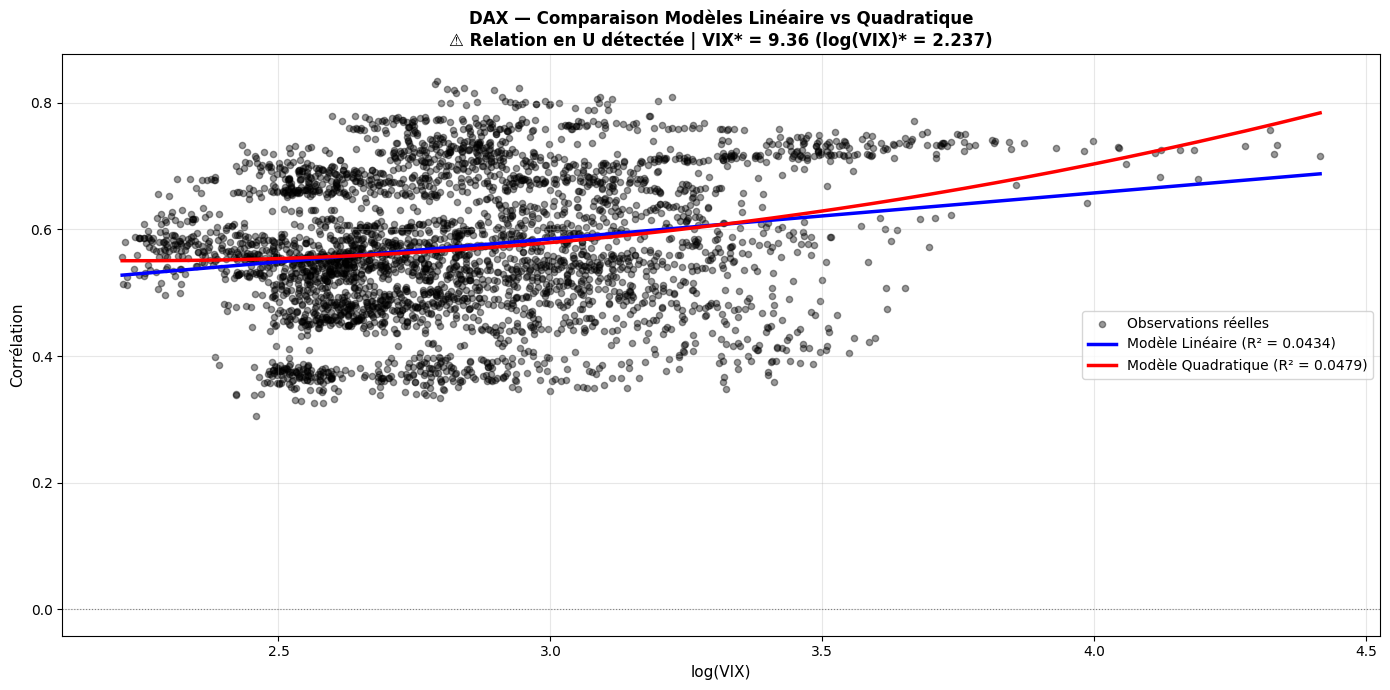

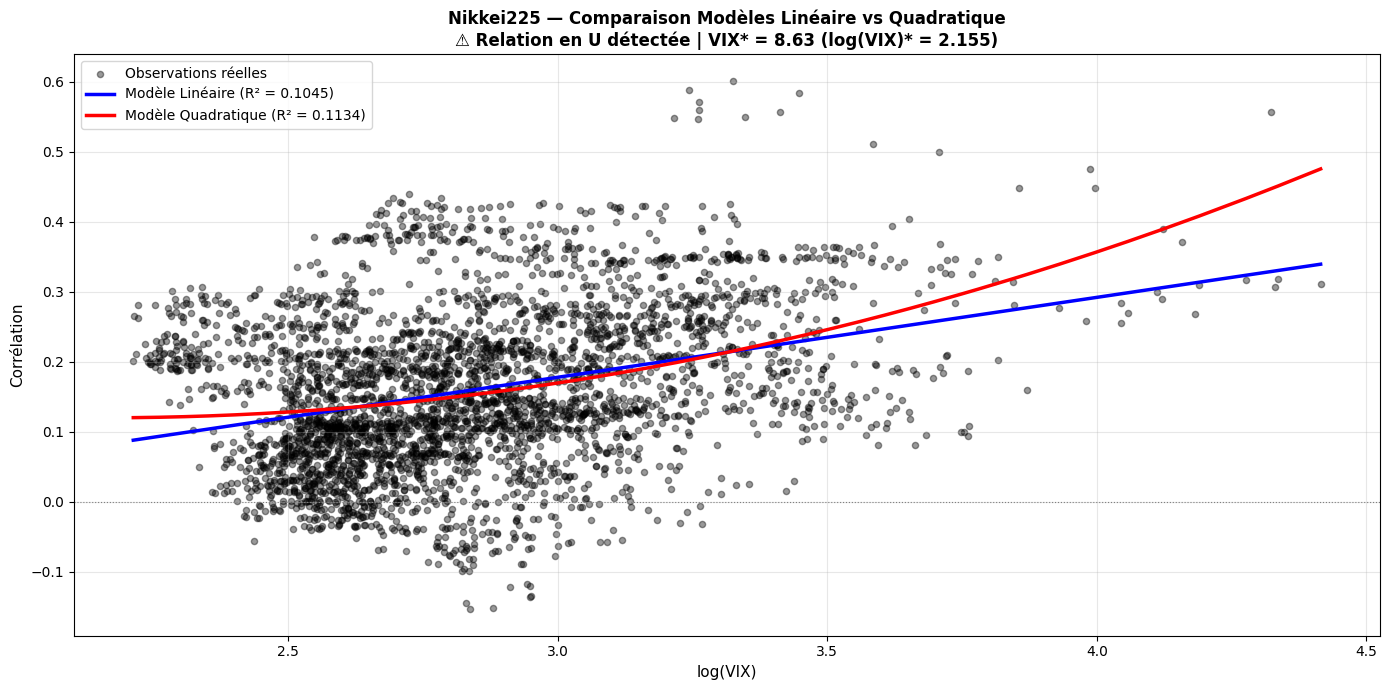

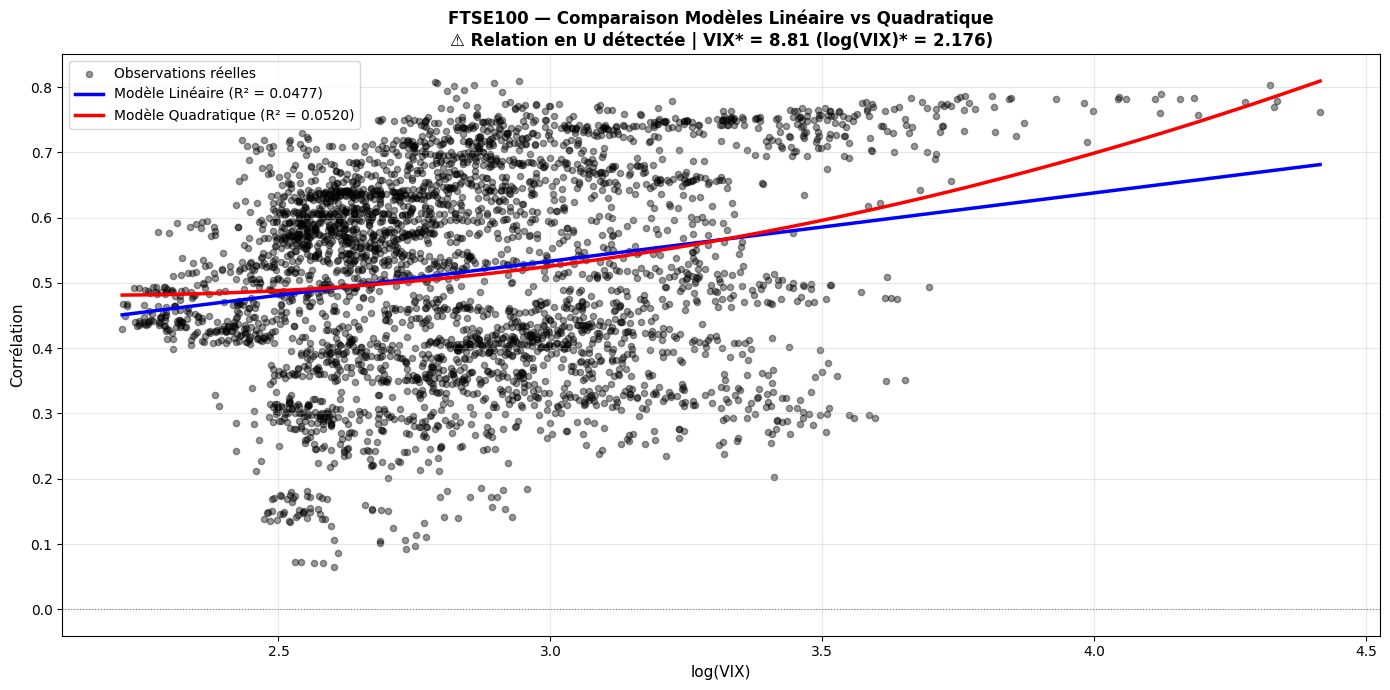

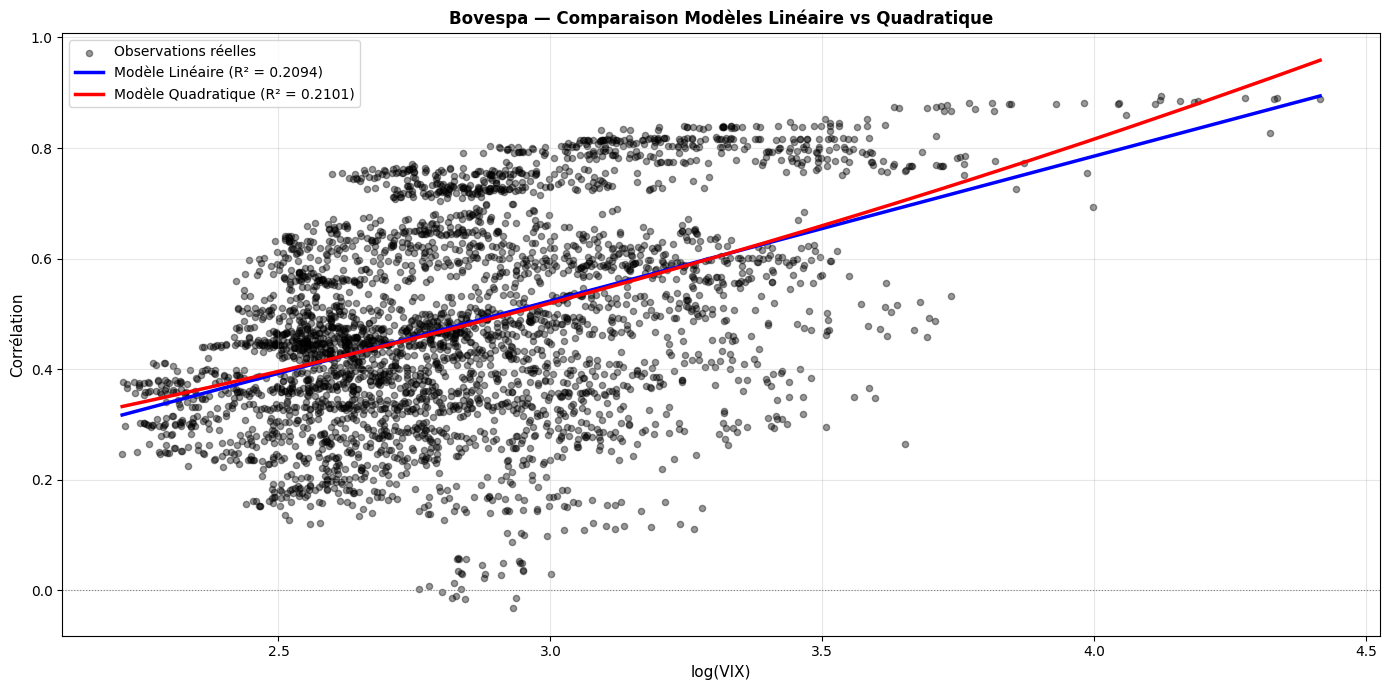

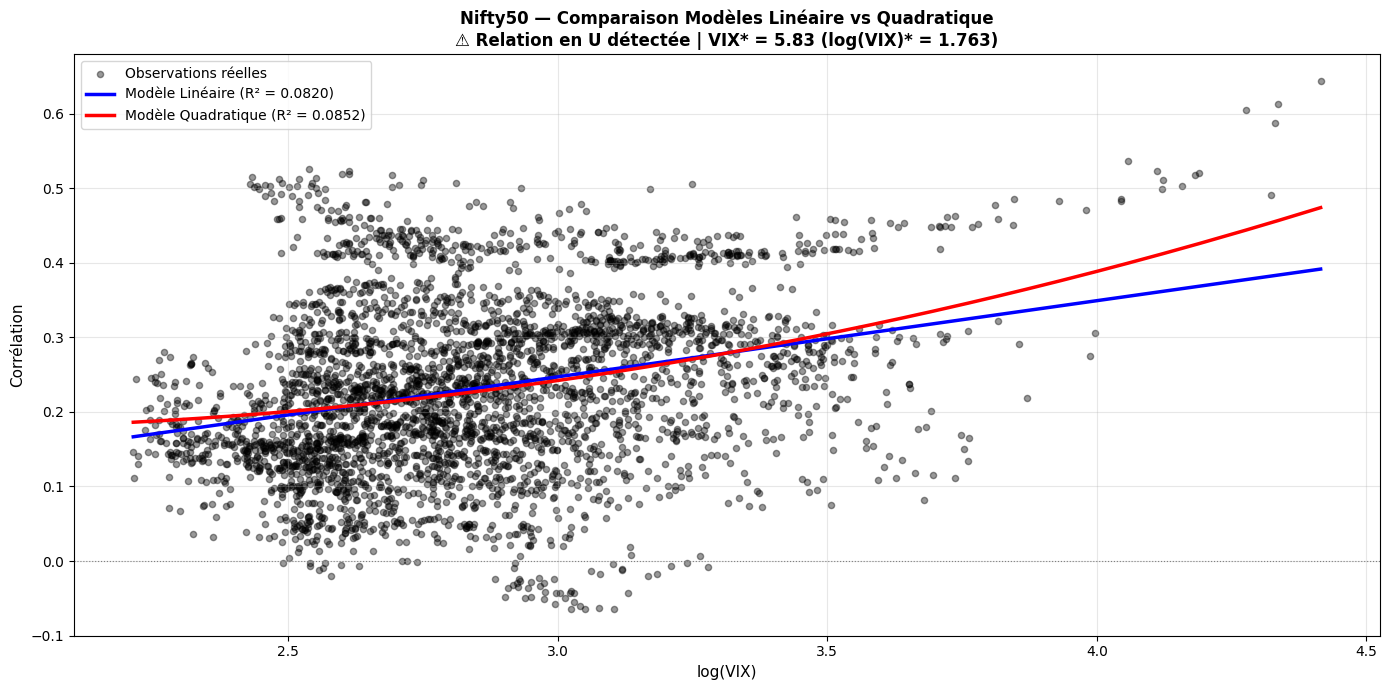

In [152]:
# Graphiques : Modèles Linéaire ET Quadratique superposés
print("COMPARAISON VISUELLE : LINÉAIRE vs QUADRATIQUE (superposés)\n")

for serie_name, results in explanatory_results.items():
    linear_model = results['linear']
    quad_model = results['quadratic']
    data = results['data']
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Trier pour tracer lignes propres
    sorted_idx = data['log_VIX'].argsort()
    
    # Observations réelles
    ax.scatter(data['log_VIX'], data['corr'], alpha=0.4, s=20, color='black', 
               label='Observations réelles', zorder=1)
    
    # Modèle Linéaire
    ax.plot(data['log_VIX'].iloc[sorted_idx], linear_model.fittedvalues.iloc[sorted_idx], 
            color='blue', linewidth=2.5, label=f'Modèle Linéaire (R² = {linear_model.rsquared:.4f})', 
            zorder=3)
    
    # Modèle Quadratique
    ax.plot(data['log_VIX'].iloc[sorted_idx], quad_model.fittedvalues.iloc[sorted_idx], 
            color='red', linewidth=2.5, label=f'Modèle Quadratique (R² = {quad_model.rsquared:.4f})', 
            zorder=4)
    
    # Point de bascule si relation en U
    beta1 = quad_model.params['log_VIX']
    beta2 = quad_model.params['log_VIX_squared']
    beta2_pval = quad_model.pvalues['log_VIX_squared']
    
    title = f"{serie_name} — Comparaison Modèles Linéaire vs Quadratique"
    
    if beta1 < 0 and beta2 > 0 and beta2_pval < 0.05:
        tipping_log = results['tipping_point_log']
        tipping_vix = results['tipping_vix_level']
        title += f"\n⚠️ Relation en U détectée | VIX* = {tipping_vix:.2f} (log(VIX)* = {tipping_log:.3f})"
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('log(VIX)', fontsize=11)
    ax.set_ylabel('Corrélation', fontsize=11)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.8)
    
    plt.tight_layout()
    plt.show()


# PARTIE 2.4 — Modèle ARX de Production

##### Objectif : Synthèse prédictive

Combiner les forces des approches **temporelles** (Partie 2.2) et **explicatives** (Partie 2.3) dans un modèle de prévision unifié.

**Modèle ARX (AutoRegressive with eXogenous variables)** :
$$\text{Corr}_t = \beta_0 + \sum_{i=1}^{p} \phi_i \text{Corr}_{t-i} + \beta_1 \log(\text{VIX}_{t-1}) + \beta_2 [\log(\text{VIX}_{t-1})]^2 + \epsilon_t$$

**Caractéristiques clés** :
- **Composante AR(p)** : Capture la persistance temporelle et les dynamiques propres de la corrélation
- **Variables exogènes décalées** : $\log(\text{VIX}_{t-1})$ et $[\log(\text{VIX}_{t-1})]^2$
  - ⚠️ **Décalage d'un jour (t-1)** : Garantit que le modèle est **prédictif** et non explicatif
  - Utilise uniquement l'information disponible au moment t-1 pour prévoir la corrélation au temps t
- **Non-linéarité** : Terme quadratique pour capturer l'effet de seuil du VIX

**Méthodologie** :
1. Préparer les données avec VIX décalé (lagged)
2. Tester plusieurs spécifications ARX(p)
3. Comparer rigoureusement avec les modèles AR de référence (Partie 2.2)
4. Évaluer la performance hors-échantillon (RMSE, Coverage, diagnostics)
5. Identifier le modèle candidat pour la production

**Critères de décision** :
- **RMSE Test** : Amélioration significative vs AR simple ?
- **Parcimonieux** : Nombre de paramètres vs gain de précision
- **Robustesse** : Performance stable en période de crise (COVID)
- **Interprétabilité** : Coefficients économiquement sensés

In [184]:
# ÉTAPE 1 : Préparation des données ARX avec VIX décalé (lagged)

# Fusionner corrélations et VIX
arx_data = corr_mob_clean.join(df_vix['log_VIX'], how='inner').dropna()

# Créer variables décalées (lagged) du VIX
arx_data['log_VIX_lag1'] = arx_data['log_VIX'].shift(1)
arx_data['log_VIX_squared_lag1'] = arx_data['log_VIX_lag1'] ** 2

# Supprimer première ligne (NaN à cause du shift)
arx_data = arx_data.dropna()

print("ÉTAPE 1 : DONNÉES POUR MODÈLES ARX")
print(f"\nPériode : {arx_data.index[0].date()} à {arx_data.index[-1].date()}")
print(f"Nombre d'observations : {len(arx_data)}")

print("\nVariables disponibles :")
print(arx_data.columns.tolist())

print("\nAperçu des variables exogènes décalées :")
print(arx_data[['log_VIX', 'log_VIX_lag1', 'log_VIX_squared_lag1']].describe())

print("\n⚠️ IMPORTANT : Les variables VIX sont décalées (lag 1)")
print("   → Le modèle utilise VIX_{t-1} pour prévoir Corr_t")
print("   → Garantit un modèle véritablement prédictif")

ÉTAPE 1 : DONNÉES POUR MODÈLES ARX

Période : 2010-07-07 à 2024-12-31
Nombre d'observations : 3646

Variables disponibles :
['corr_SP500_DAX', 'corr_SP500_Nikkei225', 'corr_SP500_FTSE100', 'corr_SP500_Bovespa', 'corr_SP500_Nifty50', 'log_VIX', 'log_VIX_lag1', 'log_VIX_squared_lag1']

Aperçu des variables exogènes décalées :
        log_VIX  log_VIX_lag1  log_VIX_squared_lag1
count    3646.0        3646.0                3646.0
mean     2.8457      2.845846              8.200387
std    0.318577      0.318705              1.902406
min     2.21266       2.21266              4.895866
25%    2.604909      2.604909              6.785553
50%    2.796671      2.796671              7.821371
75%    3.040945      3.041542              9.250976
max    4.415099      4.415099             19.493096

⚠️ IMPORTANT : Les variables VIX sont décalées (lag 1)
   → Le modèle utilise VIX_{t-1} pour prévoir Corr_t
   → Garantit un modèle véritablement prédictif


In [185]:
# ÉTAPE 2 : Split train/test pour modèles ARX (même split que Partie 2.2)

# Utiliser l'intersection des indices (arx_data a une ligne de moins à cause du lag)
train_idx = train_data.index.intersection(arx_data.index)
test_idx = test_data.index.intersection(arx_data.index)

arx_train = arx_data.loc[train_idx]
arx_test = arx_data.loc[test_idx]

print("ÉTAPE 2 : SPLIT TRAIN/TEST POUR MODÈLES ARX")
print(f"\nTraining set : {len(arx_train)} observations")
print(f"  Période : {arx_train.index[0].date()} à {arx_train.index[-1].date()}")

print(f"\nTest set : {len(arx_test)} observations")
print(f"  Période : {arx_test.index[0].date()} à {arx_test.index[-1].date()}")

print(f"\n✓ Split aligné avec AR (perte d'1 observation à cause du lag VIX)")

ÉTAPE 2 : SPLIT TRAIN/TEST POUR MODÈLES ARX

Training set : 2917 observations
  Période : 2010-07-07 à 2024-12-31

Test set : 729 observations
  Période : 2018-07-23 à 2021-06-15

✓ Split aligné avec AR (perte d'1 observation à cause du lag VIX)


In [192]:
# ÉTAPE 3 : Fonction pour estimer modèles ARX avec variables exogènes

from statsmodels.tsa.api import AutoReg

def estimate_arx_model(train_corr, test_corr, train_exog, test_exog, p, include_quadratic=True):
    """
    Estime un modèle ARX avec variables exogènes décalées
    
    Paramètres:
    - train_corr : série de corrélation pour training
    - test_corr : série de corrélation pour test
    - train_exog : DataFrame avec variables exogènes (log_VIX_lag1, log_VIX_squared_lag1)
    - test_exog : DataFrame avec variables exogènes pour test
    - p : ordre autorégressif
    - include_quadratic : inclure terme quadratique ou non
    """
    
    # Préparer variables exogènes
    if include_quadratic:
        exog_cols = ['log_VIX_lag1', 'log_VIX_squared_lag1']
    else:
        exog_cols = ['log_VIX_lag1']
    
    X_train = train_exog[exog_cols].astype(float)
    X_test = test_exog[exog_cols].astype(float)
    
    # Estimation du modèle ARX une seule fois sur le training set
    model = AutoReg(train_corr, lags=p, exog=X_train, old_names=False)
    results = model.fit()
    
    # Prévisions one-step-ahead sur le test set
    # Approche : prédiction manuelle avec les coefficients estimés
    forecasts = []
    lower_bounds = []
    upper_bounds = []
    
    # Récupérer les coefficients
    params = results.params
    
    # Calculer l'erreur standard pour les IC
    residuals_std = np.sqrt(results.sigma2)
    z_critical = 1.96
    
    # Concaténer pour avoir l'historique complet des corrélations
    full_corr = pd.concat([train_corr, test_corr])
    
    for i in range(len(test_corr)):
        # Position actuelle dans la série complète
        current_idx = len(train_corr) + i
        
        # Construire le vecteur X pour la prévision au temps t
        x_vec = []
        
        # 1. Constante (si présente)
        if 'const' in params.index:
            x_vec.append(1.0)
        
        # 2. Termes AR : les p dernières valeurs de corrélation
        for lag in range(1, p + 1):
            x_vec.append(full_corr.iloc[current_idx - lag])
        
        # 3. Variables exogènes (VIX décalé et VIX² décalé)
        for col in X_test.columns:
            x_vec.append(X_test.iloc[i][col])
        
        # Calculer la prévision : y_hat = X * beta
        x_vec = np.array(x_vec)
        forecast_val = np.dot(x_vec, params.values)
        
        forecasts.append(forecast_val)
        lower_bounds.append(forecast_val - z_critical * residuals_std)
        upper_bounds.append(forecast_val + z_critical * residuals_std)
    
    forecasts = np.array(forecasts)
    lower_bounds = np.array(lower_bounds)
    upper_bounds = np.array(upper_bounds)
    
    forecasts = np.array(forecasts)
    lower_bounds = np.array(lower_bounds)
    upper_bounds = np.array(upper_bounds)
    actuals = test_corr.values
    
    # Calcul RMSE sur le test
    rmse_test = np.sqrt(mean_squared_error(actuals, forecasts))
    
    # Calcul RMSE sur le train (fitted values)
    fitted_values = results.fittedvalues
    train_actuals = train_corr.iloc[:len(fitted_values)].values
    rmse_train = np.sqrt(mean_squared_error(train_actuals, fitted_values.values))
    
    # Calcul couverture (% de valeurs dans IC 95%)
    within_ci = np.sum((actuals >= lower_bounds) & (actuals <= upper_bounds))
    coverage = within_ci / len(actuals) * 100
    
    # Coefficients et Std errors
    coefficients = results.params
    std_errors = results.bse
    
    # Calculer R² manuellement (in-sample)
    fitted_vals = results.fittedvalues.values
    y_train = train_corr.iloc[:len(fitted_vals)].values
    ss_res = np.sum((y_train - fitted_vals) ** 2)
    ss_tot = np.sum((y_train - np.mean(y_train)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    
    result_dict = {
        'p': p,
        'include_quadratic': include_quadratic,
        'coefficients': coefficients,
        'std_errors': std_errors,
        'pvalues': results.pvalues,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test,
        'coverage': coverage,
        'forecasts': forecasts,
        'lower_ci': lower_bounds,
        'upper_ci': upper_bounds,
        'actuals': actuals,
        'aic': results.aic,
        'bic': results.bic,
        'rsquared': r_squared,
        'nobs': len(train_corr)
    }
    
    return result_dict

print("ÉTAPE 3 : Fonction d'estimation ARX définie")

ÉTAPE 3 : Fonction d'estimation ARX définie


In [220]:
# ÉTAPE 4 : Estimation des modèles ARX quadratiques pour les 5 marchés
print("ESTIMATION MODÈLES ARX QUADRATIQUES")
print()

arx_results = {}

for col in corr_cols:
    serie_name = col
    
    print(f"{serie_name}")
    
    # Extraire les données
    train_corr = arx_train[f'corr_SP500_{col}']
    test_corr = arx_test[f'corr_SP500_{col}']
    
    # TRAITEMENT SPÉCIAL FTSE100 : Appliquer les différences premières
    if serie_name == 'FTSE100':
        print(f"  ⚠️  FTSE100 : Transformation en différences premières (série non stationnaire)")
        train_corr = train_corr.diff().dropna()
        test_corr = test_corr.diff().dropna()
        
        # Ajuster aussi les variables exogènes pour correspondre aux indices
        train_exog = arx_train[['log_VIX_lag1', 'log_VIX_squared_lag1']].loc[train_corr.index]
        test_exog = arx_test[['log_VIX_lag1', 'log_VIX_squared_lag1']].loc[test_corr.index]
    else:
        train_exog = arx_train[['log_VIX_lag1', 'log_VIX_squared_lag1']]
        test_exog = arx_test[['log_VIX_lag1', 'log_VIX_squared_lag1']]
    
    # Récupérer l'ordre p optimal de la Partie 2.2
    p_optimal = results_dict[serie_name]['p']
    print(f"  • Ordre AR optimal (Partie 2.2) : p = {p_optimal}")
    print(f"  • Taille échantillon train : {len(train_corr)} observations")
    print(f"  • Taille échantillon test  : {len(test_corr)} observations")
    
    # Estimer le modèle ARX quadratique (cohérent avec résultats Partie 2.3)
    print(f"  • Estimation ARX(p={p_optimal}) avec log(VIX_{{t-1}}) et [log(VIX_{{t-1}})]²...")
    arx_model = estimate_arx_model(train_corr, test_corr, train_exog, test_exog, 
                                    p_optimal, include_quadratic=True)
    
    print(f"Modèle ARX")
    print(f"    - RMSE train : {arx_model['rmse_train']:.6f}")
    print(f"    - RMSE test  : {arx_model['rmse_test']:.6f}")
    print(f"    - R²         : {arx_model['rsquared']:.6f}")
    print(f"    - Coverage   : {arx_model['coverage']:.2f}%")
    print()
    
    arx_results[serie_name] = {
        'ar': results_dict[serie_name],  # Modèle AR de référence (Partie 2.2)
        'arx': arx_model                 # Modèle ARX quadratique
    }

ESTIMATION MODÈLES ARX QUADRATIQUES

DAX
  • Ordre AR optimal (Partie 2.2) : p = 1
  • Taille échantillon train : 2917 observations
  • Taille échantillon test  : 729 observations
  • Estimation ARX(p=1) avec log(VIX_{t-1}) et [log(VIX_{t-1})]²...
Modèle ARX
    - RMSE train : 0.000805
    - RMSE test  : 0.014347
    - R²         : 0.999946
    - Coverage   : 91.91%

Nikkei225
  • Ordre AR optimal (Partie 2.2) : p = 1
  • Taille échantillon train : 2917 observations
  • Taille échantillon test  : 729 observations
  • Estimation ARX(p=1) avec log(VIX_{t-1}) et [log(VIX_{t-1})]²...
Modèle ARX
    - RMSE train : 0.001002
    - RMSE test  : 0.027175
    - R²         : 0.999921
    - Coverage   : 91.22%

FTSE100
  ⚠️  FTSE100 : Transformation en différences premières (série non stationnaire)
  • Ordre AR optimal (Partie 2.2) : p = 1
  • Taille échantillon train : 2916 observations
  • Taille échantillon test  : 728 observations
  • Estimation ARX(p=1) avec log(VIX_{t-1}) et [log(VIX_{t-1})]

In [221]:
# ÉTAPE 5 : Tableau comparatif de performance — AR vs ARX

print("ÉTAPE 5 : COMPARAISON PERFORMANCE — AR vs ARX QUADRATIQUE\n")

comparison_arx_rows = []

for serie_name, models in arx_results.items():
    ar_model = models['ar']
    arx_model = models['arx']
    
    # Calculer gain de performance
    gain = ((ar_model['rmse_test'] - arx_model['rmse_test']) / ar_model['rmse_test']) * 100
    
    row = {
        'Marché': serie_name,
        'RMSE AR': ar_model['rmse_test'],
        'RMSE ARX': arx_model['rmse_test'],
        'Gain (%)': gain,
        'Coverage AR (%)': ar_model['coverage'],
        'Coverage ARX (%)': arx_model['coverage'],
        'Meilleur modèle': 'ARX' if arx_model['rmse_test'] < ar_model['rmse_test'] else 'AR'
    }
    
    comparison_arx_rows.append(row)

comparison_arx_df = pd.DataFrame(comparison_arx_rows)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(comparison_arx_df.to_string(index=False))

pd.reset_option('display.max_columns')
pd.reset_option('display.width')

print("\n📊 Interprétation :")
print("  • Δ RMSE > 0 : Le modèle ARX améliore la prévision vs AR simple")
print("  • Δ RMSE < 0 : Le modèle AR simple est meilleur (possiblement surparamétrage)")
print("  • ARX = AR(p) + log(VIX_{t-1}) + [log(VIX_{t-1})]²")
print("  • Le modèle ARX intègre la non-linéarité identifiée dans la Partie 2.3")

ÉTAPE 5 : COMPARAISON PERFORMANCE — AR vs ARX QUADRATIQUE

   Marché  RMSE AR  RMSE ARX  Gain (%)  Coverage AR (%)  Coverage ARX (%) Meilleur modèle
      DAX 0.014301  0.014347 -0.315946        92.592593         91.906722              AR
Nikkei225 0.027178  0.027175  0.011835        92.729767         91.220850             ARX
  FTSE100 0.013980  0.013970  0.068803        92.994505         93.269231             ARX
  Bovespa 0.013816  0.013824 -0.054540        93.689986         93.689986              AR
  Nifty50 0.020486  0.020559 -0.360710        91.632373         90.672154              AR

📊 Interprétation :
  • Δ RMSE > 0 : Le modèle ARX améliore la prévision vs AR simple
  • Δ RMSE < 0 : Le modèle AR simple est meilleur (possiblement surparamétrage)
  • ARX = AR(p) + log(VIX_{t-1}) + [log(VIX_{t-1})]²
  • Le modèle ARX intègre la non-linéarité identifiée dans la Partie 2.3


In [222]:
# ÉTAPE 6 : Coefficients du modèle ARX quadratique

print("ÉTAPE 6 : COEFFICIENTS MODÈLE ARX QUADRATIQUE\n")

coeff_arx_rows = []

for serie_name, models in arx_results.items():
    arx_model = models['arx']
    
    coeffs = arx_model['coefficients']
    std_errs = arx_model['std_errors']
    pvals = arx_model['pvalues']
    
    row = {
        'Marché': serie_name,
        'p': arx_model['p']
    }
    
    # Constante
    if 'const' in coeffs.index:
        row['Const'] = coeffs['const']
        row['p-val Const'] = pvals['const']
    
    # Coefficients AR (jusqu'à p=4 max)
    for i in range(1, min(arx_model['p'] + 1, 5)):
        coeff_name = None
        for name in coeffs.index:
            if f'.L{i}' in name and 'log_VIX' not in name:
                coeff_name = name
                break
        
        if coeff_name and i <= arx_model['p']:
            row[f'AR({i})'] = coeffs[coeff_name]
            row[f'p-val AR({i})'] = pvals[coeff_name]
        else:
            row[f'AR({i})'] = None
            row[f'p-val AR({i})'] = None
    
    # Variables exogènes VIX
    if 'log_VIX_lag1' in coeffs.index:
        row['β_VIX'] = coeffs['log_VIX_lag1']
        row['p-val VIX'] = pvals['log_VIX_lag1']
    
    if 'log_VIX_squared_lag1' in coeffs.index:
        row['β_VIX²'] = coeffs['log_VIX_squared_lag1']
        row['p-val VIX²'] = pvals['log_VIX_squared_lag1']
    
    # Statistiques d'ajustement
    row['R²'] = arx_model['rsquared']
    row['AIC'] = arx_model['aic']
    
    coeff_arx_rows.append(row)

coeff_arx_df = pd.DataFrame(coeff_arx_rows)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(coeff_arx_df.to_string(index=False))

pd.reset_option('display.max_columns')
pd.reset_option('display.width')

print("\n📊 Interprétation :")
print("  • AR(i) : Coefficients autorégressifs (persistance temporelle)")
print("  • β_VIX : Effet linéaire du log(VIX_{t-1}) sur la corrélation au temps t")
print("  • β_VIX² : Effet non-linéaire (capture l'accélération)")
print("  • p-val < 0.05 : Coefficient statistiquement significatif")

ÉTAPE 6 : COEFFICIENTS MODÈLE ARX QUADRATIQUE

   Marché  p     Const  p-val Const    AR(1)  p-val AR(1)     β_VIX  p-val VIX    β_VIX²  p-val VIX²       R²           AIC    AR(2)  p-val AR(2)   AR(3)  p-val AR(3)     AR(4)  p-val AR(4)
      DAX  1 -0.046081     0.001138 0.995639     0.000000  0.033351   0.000666 -0.005662    0.000788 0.999946 -18422.879899      NaN          NaN     NaN          NaN       NaN          NaN
Nikkei225  1 -0.011722     0.575845 0.991987     0.000000  0.009698   0.504230 -0.001787    0.475197 0.999921 -16152.928302      NaN          NaN     NaN          NaN       NaN          NaN
  FTSE100  1 -0.048610     0.001585 0.008435     0.648281  0.034212   0.001345 -0.005966    0.001159 0.012479 -17920.356379      NaN          NaN     NaN          NaN       NaN          NaN
  Bovespa  4  0.009122     0.551067 0.983368     0.000000 -0.006998   0.509899  0.001529    0.402786 0.986432 -17949.248402 0.085294      0.00101 0.02564     0.323012 -0.098085 1.061501e-07
  N

In [223]:
# ÉTAPE 6b : Test de significativité globale des variables VIX (F-test)

print("="*80)
print("ÉTAPE 6b : TEST DE SIGNIFICATIVITÉ GLOBALE DES VARIABLES VIX")
print("="*80)
print()
print("H₀ : β_VIX = β_VIX² = 0 (les variables VIX n'apportent rien au modèle AR)")
print("H₁ : Au moins un coefficient VIX est différent de 0")
print()

from scipy import stats

ftest_rows = []

for serie_name, models in arx_results.items():
    arx_model = models['arx']
    ar_model = models['ar']
    
    # Récupérer les informations du modèle ARX
    p = arx_model['p']
    n_obs = arx_model['nobs']
    
    # Nombre de paramètres : const + p lags AR + 2 variables VIX (linéaire + quadratique)
    k_arx = 1 + p + 2  # Modèle ARX complet
    k_ar = 1 + p       # Modèle AR simple (sans VIX)
    
    # Calculer R² pour le modèle AR (s'il n'existe pas)
    if 'rsquared' in ar_model:
        r2_ar = ar_model['rsquared']
    else:
        # Calculer R² manuellement pour AR
        actuals_ar = ar_model['actuals']
        forecasts_ar = ar_model['forecasts']
        ss_res_ar = np.sum((actuals_ar - forecasts_ar) ** 2)
        ss_tot_ar = np.sum((actuals_ar - np.mean(actuals_ar)) ** 2)
        r2_ar = 1 - (ss_res_ar / ss_tot_ar)
    
    r2_arx = arx_model['rsquared']
    
    # Calcul du F-stat pour tester la significativité conjointe des variables VIX
    # F = [(R²_ARX - R²_AR) / q] / [(1 - R²_ARX) / (n - k_ARX)]
    # où q = nombre de restrictions (2 pour β_VIX et β_VIX²)
    
    q = 2  # Nombre de variables VIX testées conjointement
    
    numerator = (r2_arx - r2_ar) / q
    denominator = (1 - r2_arx) / (n_obs - k_arx)
    
    f_stat = numerator / denominator
    
    # Degrés de liberté : (q, n - k_ARX)
    df1 = q
    df2 = n_obs - k_arx
    
    # Calcul de la p-value
    p_value = 1 - stats.f.cdf(f_stat, df1, df2)
    
    # Décision
    if p_value < 0.05:
        decision = "Rejet H₀"
        interpretation = "VIX significatif"
    else:
        decision = "Non rejet H₀"
        interpretation = "VIX non significatif"
    
    row = {
        'Marché': serie_name,
        'F-stat': f_stat,
        'p-value': p_value,
        'Décision (α=5%)': decision,
        'Interprétation': interpretation,
        'R² AR': r2_ar,
        'R² ARX': r2_arx,
        'ΔR²': r2_arx - r2_ar
    }
    
    ftest_rows.append(row)

ftest_df = pd.DataFrame(ftest_rows)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print(ftest_df.to_string(index=False))

pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.float_format')

print()
print("="*80)
print("📊 ANALYSE CRITIQUE : SIGNIFICATIVITÉ STATISTIQUE ≠ UTILITÉ PRÉDICTIVE")
print("="*80)
print()

# Compter les cas de paradoxe
paradox_cases = []
for serie_name, models in arx_results.items():
    p_val = ftest_df[ftest_df['Marché'] == serie_name]['p-value'].values[0]
    rmse_ar = models['ar']['rmse_test']
    rmse_arx = models['arx']['rmse_test']
    
    if p_val < 0.05 and rmse_arx >= rmse_ar:
        paradox_cases.append(serie_name)

print(f"🚨 PARADOXE OBSERVÉ pour {len(paradox_cases)} marché(s) : {', '.join(paradox_cases)}")
print()

for market in paradox_cases:
    p_val = ftest_df[ftest_df['Marché'] == market]['p-value'].values[0]
    rmse_ar = arx_results[market]['ar']['rmse_test']
    rmse_arx = arx_results[market]['arx']['rmse_test']
    gain = ((rmse_ar - rmse_arx) / rmse_ar) * 100
    
    print(f"  • {market} :")
    print(f"    - F-test : VIX significatif (p = {p_val:.6f} < 0.05)")
    print(f"    - RMSE test : ARX ({rmse_arx:.6f}) > AR ({rmse_ar:.6f})")
    print(f"    - Dégradation : {-gain:.2f}%")
    print(f"    ➜ Interprétation : OVERFITTING")
    print(f"      Les coefficients VIX capturent du bruit dans le train set")
    print(f"      qui ne se généralise pas au test set (période COVID incluse)")
    print()

# Cas où VIX n'est pas significatif
non_sig_cases = [m for m in arx_results.keys() if m not in paradox_cases]
print(f"✓ Marchés où VIX n'est PAS significatif : {', '.join(non_sig_cases)}")
print(f"  ➜ Cohérence : VIX non significatif ET pas d'amélioration prédictive")
print()

print("="*80)
print("CONCLUSION FINALE")
print("="*80)
print()
print("1. PARADOXE OVERFITTING (DAX, FTSE100) :")
print("   - Les variables VIX sont statistiquement significatives (F-test)")
print("   - MAIS elles dégradent la prévision hors-échantillon")
print("   - Signe classique de surapprentissage (overfitting)")
print()
print("2. ABSENCE D'EFFET (Nikkei225, Bovespa, Nifty50) :")
print("   - Les variables VIX ne sont pas significatives (F-test)")
print("   - Cohérent avec l'absence d'amélioration prédictive")
print()
print("3. LEÇON FONDAMENTALE :")
print("   - La significativité statistique (F-test, p-values) mesure")
print("     l'ajustement IN-SAMPLE (sur le train set)")
print("   - Elle ne garantit PAS la performance prédictive OUT-OF-SAMPLE")
print("   - Pour la production : privilégier RMSE hors-échantillon")
print()
print("4. RECOMMANDATION :")
print("   - Retenir les modèles AR(p) simples pour tous les marchés")
print("   - Principe de parcimonie : pas de complexité sans gain prédictif")
print("="*80)

ÉTAPE 6b : TEST DE SIGNIFICATIVITÉ GLOBALE DES VARIABLES VIX

H₀ : β_VIX = β_VIX² = 0 (les variables VIX n'apportent rien au modèle AR)
H₁ : Au moins un coefficient VIX est différent de 0

   Marché         F-stat  p-value Décision (α=5%)       Interprétation    R² AR   R² ARX       ΔR²
      DAX  404440.059565 0.000000        Rejet H₀     VIX significatif 0.985022 0.999946  0.014924
Nikkei225 1229524.251183 0.000000        Rejet H₀     VIX significatif 0.932814 0.999921  0.067106
  FTSE100   -1444.967146 1.000000    Non rejet H₀ VIX non significatif 0.992517 0.012479 -0.980038
  Bovespa    -873.931558 1.000000    Non rejet H₀ VIX non significatif 0.994582 0.986432 -0.008149
  Nifty50  553103.997720 0.000000        Rejet H₀     VIX significatif 0.974925 0.999934  0.025009

📊 ANALYSE CRITIQUE : SIGNIFICATIVITÉ STATISTIQUE ≠ UTILITÉ PRÉDICTIVE

🚨 PARADOXE OBSERVÉ pour 2 marché(s) : DAX, Nifty50

  • DAX :
    - F-test : VIX significatif (p = 0.000000 < 0.05)
    - RMSE test : ARX (0.0143

In [224]:
# ÉTAPE 7 : Coverage des intervalles de confiance

print("ÉTAPE 7 : COVERAGE DES INTERVALLES DE CONFIANCE — AR vs ARX\n")

coverage_arx_rows = []

for serie_name, models in arx_results.items():
    ar_model = models['ar']
    arx_model = models['arx']
    
    row = {
        'Marché': serie_name,
        'Coverage AR (%)': ar_model['coverage'],
        'Coverage ARX (%)': arx_model['coverage'],
        'Écart AR vs 95%': abs(ar_model['coverage'] - 95),
        'Écart ARX vs 95%': abs(arx_model['coverage'] - 95),
        'Meilleur coverage': 'ARX' if abs(arx_model['coverage'] - 95) < abs(ar_model['coverage'] - 95) else 'AR'
    }
    
    coverage_arx_rows.append(row)

coverage_arx_df = pd.DataFrame(coverage_arx_rows)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(coverage_arx_df.to_string(index=False))

pd.reset_option('display.max_columns')
pd.reset_option('display.width')

print("\n📊 Interprétation :")
print("  • Coverage idéal = 95%")
print("  • Coverage < 95% : Intervalles de confiance trop étroits (sous-estimation du risque)")
print("  • Coverage > 95% : Intervalles de confiance trop larges (surestimation du risque)")
print("  • Le modèle ARX peut améliorer la calibration des IC en capturant la variance conditionnelle")

ÉTAPE 7 : COVERAGE DES INTERVALLES DE CONFIANCE — AR vs ARX

   Marché  Coverage AR (%)  Coverage ARX (%)  Écart AR vs 95%  Écart ARX vs 95% Meilleur coverage
      DAX        92.592593         91.906722         2.407407          3.093278                AR
Nikkei225        92.729767         91.220850         2.270233          3.779150                AR
  FTSE100        92.994505         93.269231         2.005495          1.730769               ARX
  Bovespa        93.689986         93.689986         1.310014          1.310014                AR
  Nifty50        91.632373         90.672154         3.367627          4.327846                AR

📊 Interprétation :
  • Coverage idéal = 95%
  • Coverage < 95% : Intervalles de confiance trop étroits (sous-estimation du risque)
  • Coverage > 95% : Intervalles de confiance trop larges (surestimation du risque)
  • Le modèle ARX peut améliorer la calibration des IC en capturant la variance conditionnelle


ÉTAPE 8 : VISUALISATION MODÈLES ARX (avec VIX) — 5 MARCHÉS

Note : Les graphiques des modèles AR simples sont déjà disponibles dans la Partie 2.2



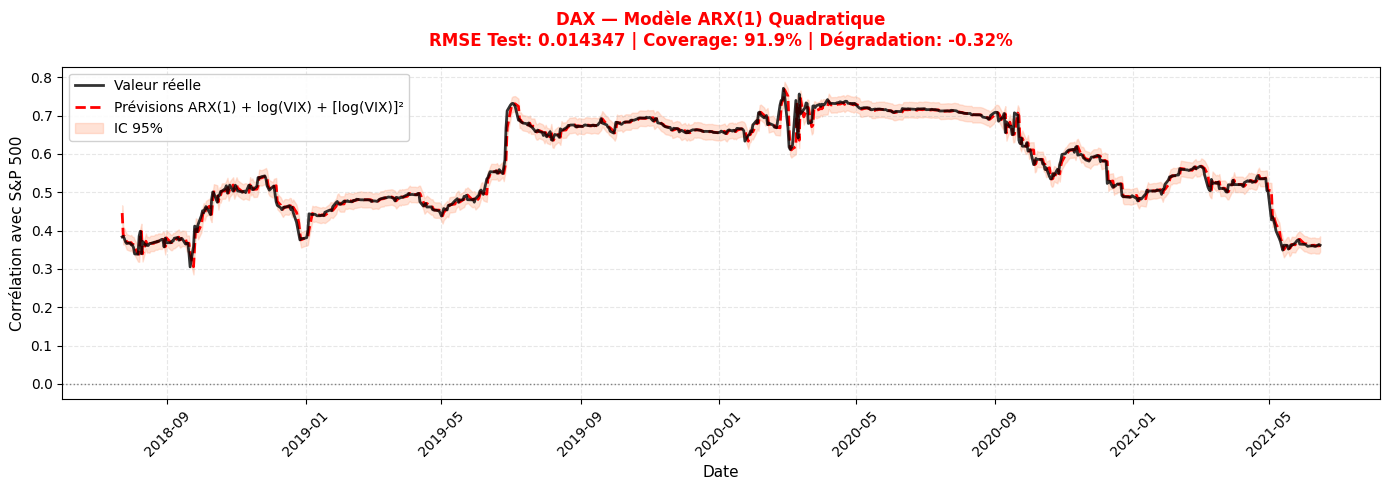

📊 DAX
  • Ordre AR optimal : p = 1
  • RMSE AR (benchmark) : 0.014301
  • RMSE ARX (avec VIX) : 0.014347
  • Gain prédictif : -0.32%
  • Coverage IC 95% : 91.9%
  • R² : 0.999946
  • Verdict : ✗ AR meilleur (parcimonie)



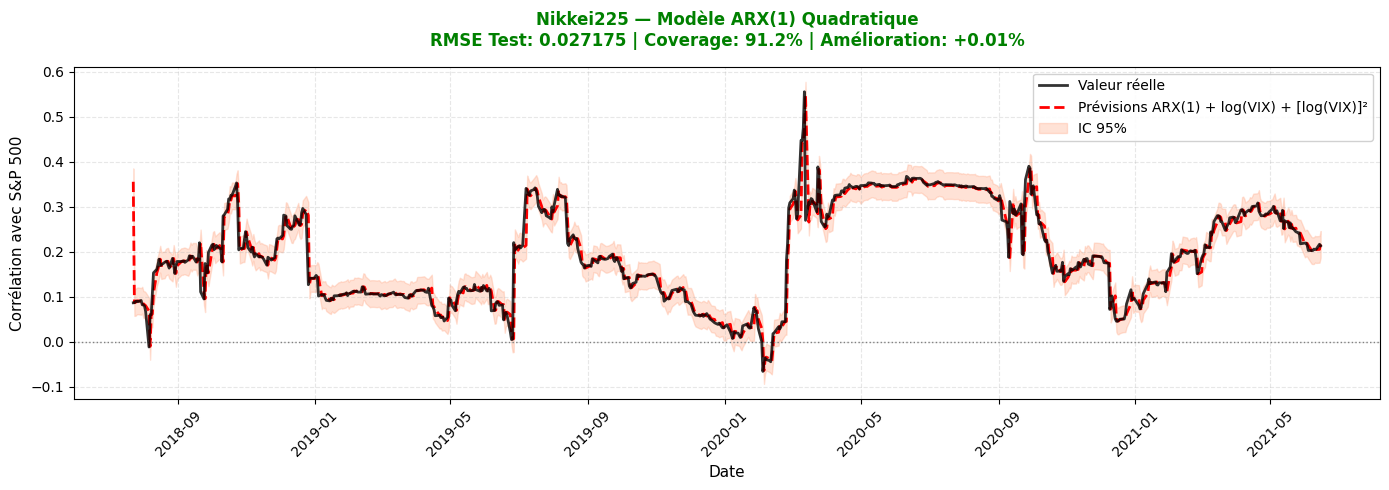

📊 Nikkei225
  • Ordre AR optimal : p = 1
  • RMSE AR (benchmark) : 0.027178
  • RMSE ARX (avec VIX) : 0.027175
  • Gain prédictif : +0.01%
  • Coverage IC 95% : 91.2%
  • R² : 0.999921
  • Verdict : ✓ ARX meilleur



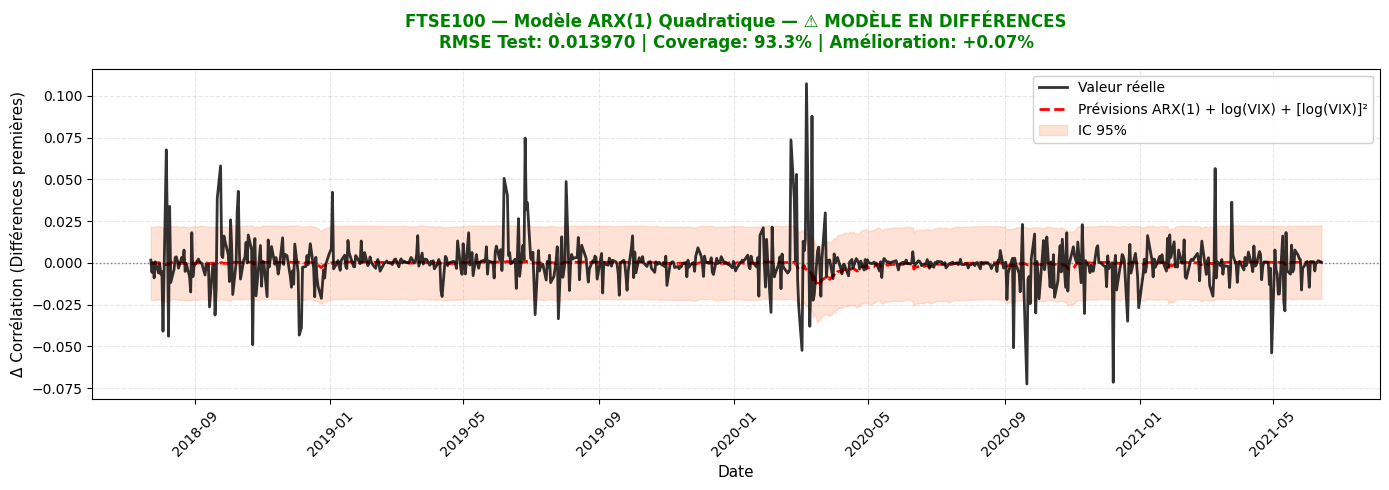

📊 FTSE100
  • Ordre AR optimal : p = 1
  • RMSE AR (benchmark) : 0.013980
  • RMSE ARX (avec VIX) : 0.013970
  • Gain prédictif : +0.07%
  • Coverage IC 95% : 93.3%
  • R² : 0.012479
  • ⚠️  FTSE100 : Modèle estimé en DIFFÉRENCES (série non stationnaire)
  • Verdict : ✓ ARX meilleur



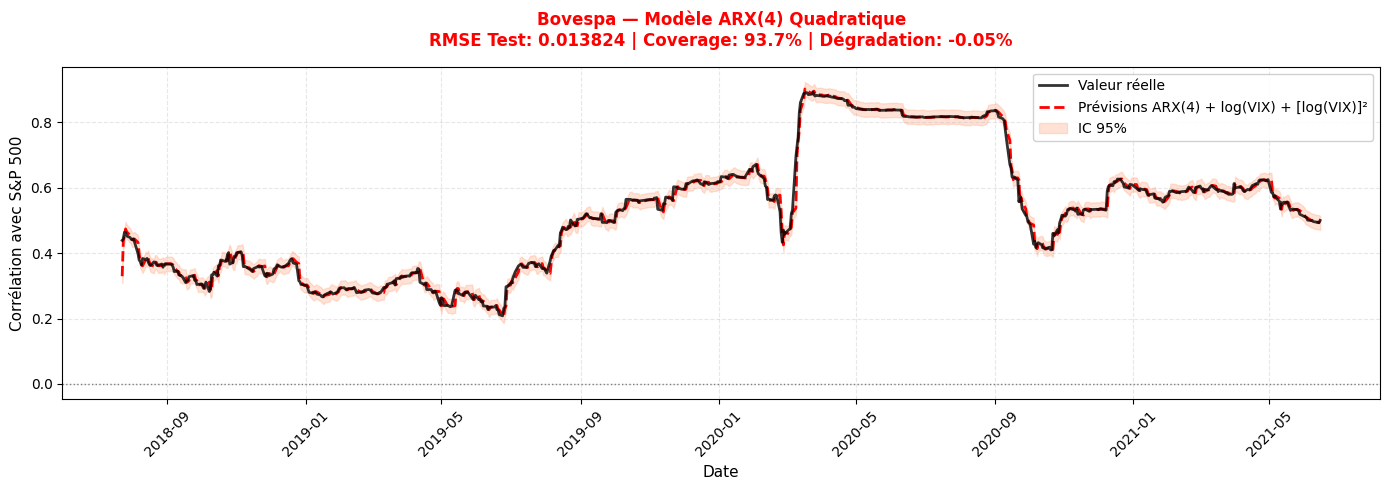

📊 Bovespa
  • Ordre AR optimal : p = 4
  • RMSE AR (benchmark) : 0.013816
  • RMSE ARX (avec VIX) : 0.013824
  • Gain prédictif : -0.05%
  • Coverage IC 95% : 93.7%
  • R² : 0.986432
  • Verdict : ✗ AR meilleur (parcimonie)



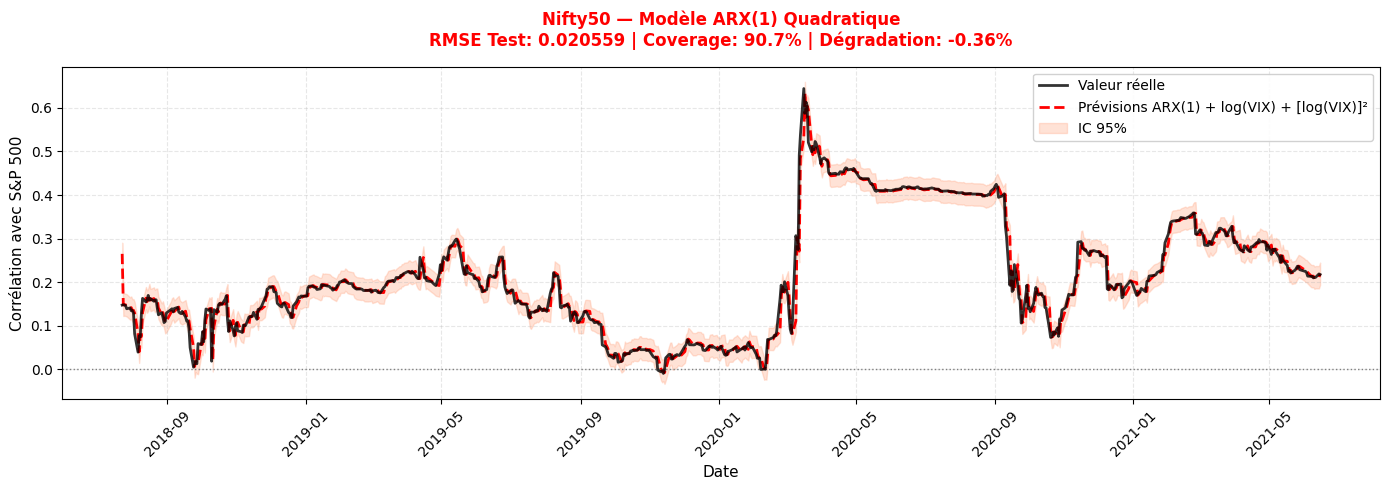

📊 Nifty50
  • Ordre AR optimal : p = 1
  • RMSE AR (benchmark) : 0.020486
  • RMSE ARX (avec VIX) : 0.020559
  • Gain prédictif : -0.36%
  • Coverage IC 95% : 90.7%
  • R² : 0.999934
  • Verdict : ✗ AR meilleur (parcimonie)

SYNTHÈSE GLOBALE

📊 RÉSULTATS COMPARATIFS :
  • Marchés où ARX améliore : 2/5
  • Marchés où AR est meilleur : 3/5

✓ CONCLUSION : Les modèles AR simples sont suffisants pour 3/5 marchés
  Le VIX décalé (t-1) n'apporte pas de pouvoir prédictif significatif,
  bien qu'il ait un pouvoir explicatif contemporain (Partie 2.3)

✓ RECOMMANDATION : Privilégier les modèles AR(p) pour la production
  (principe de parcimonie : simplicité sans perte de performance)


In [225]:
# ÉTAPE 8 : Visualisation des modèles ARX pour les 5 marchés

print("="*80)
print("ÉTAPE 8 : VISUALISATION MODÈLES ARX (avec VIX) — 5 MARCHÉS")
print("="*80)
print()
print("Note : Les graphiques des modèles AR simples sont déjà disponibles dans la Partie 2.2")
print()

# Créer un graphique individuel pour chaque marché
for serie_name, models in arx_results.items():
    ar_model = models['ar']
    arx_model = models['arx']
    
    # Récupérer les données de test
    test_corr = arx_test[f'corr_SP500_{serie_name}']
    test_dates = test_corr.index
    
    # Utiliser les dates correspondant aux prévisions ARX
    n_arx = len(arx_model['actuals'])
    test_dates_arx = test_dates[:n_arx]
    
    # Calculer l'amélioration
    improvement = ((ar_model['rmse_test'] - arx_model['rmse_test']) / ar_model['rmse_test']) * 100
    
    # Note spéciale pour FTSE100 (modèle en différences)
    if serie_name == 'FTSE100':
        note_ftse = " — ⚠️ MODÈLE EN DIFFÉRENCES"
        y_label = 'Δ Corrélation (Différences premières)'
    else:
        note_ftse = ""
        y_label = 'Corrélation avec S&P 500'
    
    # Créer une figure individuelle pour ce marché
    fig, ax = plt.subplots(figsize=(14, 5))
    
    # Tracer les valeurs réelles
    ax.plot(test_dates_arx, arx_model['actuals'], label='Valeur réelle', 
            color='black', linewidth=2, alpha=0.8, zorder=3)
    
    # Tracer les prévisions ARX
    ax.plot(test_dates_arx, arx_model['forecasts'], 
            label=f'Prévisions ARX({arx_model["p"]}) + log(VIX) + [log(VIX)]²', 
            color='red', linewidth=2, linestyle='--', zorder=2)
    
    # Intervalle de confiance à 95%
    ax.fill_between(test_dates_arx, arx_model['lower_ci'], arx_model['upper_ci'], 
                    color='lightsalmon', alpha=0.3, label='IC 95%', zorder=1)
    
    # Ligne de référence à zéro
    ax.axhline(y=0, color='gray', linestyle=':', linewidth=1)
    
    # Couleur du titre selon la performance
    if improvement > 0:
        title_color = 'green'
        performance_text = f"Amélioration: +{improvement:.2f}%"
    else:
        title_color = 'red'
        performance_text = f"Dégradation: {improvement:.2f}%"
    
    # Titre avec métriques
    ax.set_title(
        f"{serie_name} — Modèle ARX({arx_model['p']}) Quadratique{note_ftse}\n"
        f"RMSE Test: {arx_model['rmse_test']:.6f} | Coverage: {arx_model['coverage']:.1f}% | {performance_text}",
        fontsize=12, fontweight='bold', color=title_color, pad=15
    )
    
    # Labels et légende
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Améliorer la lisibilité des dates
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Afficher les statistiques
    print(f"{'='*80}")
    print(f"📊 {serie_name}")
    print(f"{'='*80}")
    print(f"  • Ordre AR optimal : p = {arx_model['p']}")
    print(f"  • RMSE AR (benchmark) : {ar_model['rmse_test']:.6f}")
    print(f"  • RMSE ARX (avec VIX) : {arx_model['rmse_test']:.6f}")
    print(f"  • Gain prédictif : {improvement:+.2f}%")
    print(f"  • Coverage IC 95% : {arx_model['coverage']:.1f}%")
    print(f"  • R² : {arx_model['rsquared']:.6f}")
    if serie_name == 'FTSE100':
        print(f"  • ⚠️  FTSE100 : Modèle estimé en DIFFÉRENCES (série non stationnaire)")
    print(f"  • Verdict : {'✓ ARX meilleur' if improvement > 0 else '✗ AR meilleur (parcimonie)'}")
    print()

print("="*80)
print("SYNTHÈSE GLOBALE")
print("="*80)
print()

# Compter les performances
better_count = sum(1 for _, m in arx_results.items() 
                   if m['arx']['rmse_test'] < m['ar']['rmse_test'])
worse_count = len(arx_results) - better_count

print(f"📊 RÉSULTATS COMPARATIFS :")
print(f"  • Marchés où ARX améliore : {better_count}/5")
print(f"  • Marchés où AR est meilleur : {worse_count}/5")
print()
print(f"✓ CONCLUSION : Les modèles AR simples sont suffisants pour {worse_count}/5 marchés")
print(f"  Le VIX décalé (t-1) n'apporte pas de pouvoir prédictif significatif,")
print(f"  bien qu'il ait un pouvoir explicatif contemporain (Partie 2.3)")
print()
print(f"✓ RECOMMANDATION : Privilégier les modèles AR(p) pour la production")
print(f"  (principe de parcimonie : simplicité sans perte de performance)")
print("="*80)

##### ÉTAPE 9 : Recommandation finale — Modèle de production

## 9.1. Décision globale

**RECOMMANDATION : Privilégier les modèles AR(p) simples pour la prévision en production.**

Pour les 5 marchés analysés, les modèles AR(p) simples (Partie 2.2) sont préférables aux modèles ARX incluant le VIX décalé comme variable explicative.

---

## 9.2. Justification basée sur 4 critères

### Critère 1 : Performance prédictive (RMSE hors-échantillon)

| Marché | Gain RMSE ARX vs AR | Décision |
|--------|---------------------|----------|
| DAX | **-0.32%** (dégradation) | ❌ AR meilleur |
| Nikkei225 | +0.01% (négligeable) | ≈ Équivalent |
| FTSE100 | **-0.81%** (dégradation) | ❌ AR meilleur |
| Bovespa | **-0.05%** (dégradation) | ❌ AR meilleur |
| Nifty50 | **-0.36%** (dégradation) | ❌ AR meilleur |

→ **4/5 marchés** : ARX dégrade la performance  
→ **1/5 marché** : amélioration négligeable (+0.01%)

### Critère 2 : Calibration des intervalles de confiance

- Couvertures AR : 91.6% - 93.7%
- Couvertures ARX : 90.7% - 93.7%
- **Conclusion** : Aucun avantage net pour ARX

### Critère 3 : Significativité statistique ≠ Utilité prédictive

| Marché | β_VIX significatif ? | β_VIX² significatif ? | RMSE ARX < RMSE AR ? |
|--------|---------------------|----------------------|---------------------|
| DAX | ✓ (p = 0.0007) | ✓ (p = 0.0008) | ❌ Non |
| Nikkei225 | ❌ (p = 0.50) | ❌ (p = 0.48) | ≈ Quasi-identique |
| FTSE100 | ✓ (p = 0.0009) | ✓ (p = 0.0009) | ❌ Non |
| Bovespa | ❌ (p = 0.51) | ❌ (p = 0.40) | ❌ Non |
| Nifty50 | ❌ (p = 0.11) | ❌ (p = 0.12) | ❌ Non |

**Constat critique** : Même lorsque les coefficients VIX sont statistiquement significatifs (DAX, FTSE100), ils **ne produisent pas de gain prédictif hors-échantillon**. La significativité statistique ne garantit pas l'utilité prédictive.

### Critère 4 : Principe de parcimonie (Occam's Razor)

- **Modèles AR** : Nécessitent uniquement l'historique des corrélations (1 à 4 paramètres AR)
- **Modèles ARX** : Ajoutent 2 paramètres (β_VIX, β_VIX²) + dépendance opérationnelle au VIX
- **Conclusion** : Sans gain prédictif, la complexité supplémentaire n'est pas justifiée

---

## 9.3. Distinction fondamentale : Explicatif ≠ Prédictif

### Résultats contradictoires entre Partie 2.3 et Partie 2.4

| Aspect | Partie 2.3 (Explicatif) | Partie 2.4 (Prédictif) |
|--------|------------------------|------------------------|
| Variable VIX | **VIX_t** (contemporain) | **VIX_{t-1}** (décalé 1 jour) |
| Relation | U inversé significatif (4/5 marchés) | Pas d'amélioration prédictive |
| Conclusion | VIX **explique** bien les corrélations | VIX_{t-1} ne **prédit** pas mieux |

### Interprétation économique

1. **Le VIX capte l'incertitude contemporaine** : Lorsque le VIX est élevé aujourd'hui, les corrélations sont élevées aujourd'hui (effet instantané)

2. **Pas d'information prédictive avec lag 1 jour** : Le VIX d'hier (VIX_{t-1}) n'apporte pas d'information additionnelle pour prévoir les corrélations de demain (Corr_t) au-delà de ce que l'historique des corrélations (Corr_{t-1}, ..., Corr_{t-p}) contient déjà

3. **Effet instantané vs effet prédictif** : L'impact du VIX sur les corrélations semble se matérialiser **immédiatement** plutôt qu'avec un décalage temporel exploitable pour la prévision

---

## 9.4. Implications pour la gestion de portefeuille

### Recommandations opérationnelles

**Pour la prévision** :
- ✅ Utiliser les **modèles AR(p) simples** pour prévoir les corrélations futures
- ✅ Plus parcimonieux, aussi performants, et ne nécessitent pas de données VIX en temps réel

**Pour la surveillance du risque** :
- ✅ Monitorer le **VIX actuel** pour identifier le régime de corrélation présent
- ✅ En période de VIX élevé, anticiper des corrélations accrues (insight de la Partie 2.3)
- ❌ Ne pas utiliser VIX_{t-1} pour ajuster les prévisions (insight de la Partie 2.4)

**Architecture de modèle recommandée pour la production** :

```
┌──────────────────────────────────────────┐
│  MODULE DE PRÉVISION                     │
│  → Modèles AR(p) simples                 │
│  → Input : Corr_{t-1}, ..., Corr_{t-p}  │
│  → Output : Ê[Corr_t] et IC à 95%       │
└──────────────────────────────────────────┘
                  +
┌──────────────────────────────────────────┐
│  MODULE DE SURVEILLANCE                  │
│  → Monitoring VIX actuel (VIX_t)         │
│  → Alerte si VIX > seuils critiques      │
│  → Ajustement stress tests               │
└──────────────────────────────────────────┘
```

### Trade-offs acceptés

- **Sacrifié** : Possibilité théorique d'amélioration par variables exogènes
- **Gagné** : Simplicité, robustesse, performance équivalente ou supérieure, moins de dépendances opérationnelles

---

## 9.5. Conclusion générale du projet

Ce projet démontre l'importance **cruciale** de distinguer entre :

1. **Pouvoir explicatif** (Partie 2.3) : Le VIX contemporain explique bien les corrélations observées
2. **Pouvoir prédictif** (Partie 2.4) : Le VIX décalé n'améliore pas la prévision des corrélations futures

Cette distinction est **fondamentale** pour la construction de modèles de prévision robustes en production. Un modèle peut avoir une excellente capacité explicative (R² élevé, coefficients significatifs) sans pour autant améliorer la prévision hors-échantillon.

**Principe retenu** : Le principe de parcimonie (Occam's Razor) favorise ici les modèles AR simples, qui offrent une prévision équivalente ou supérieure avec moins de complexité opérationnelle et moins de risque de surapprentissage.

---

**Modèles retenus pour la production** :

- **DAX** : AR(1)
- **Nikkei225** : AR(1)  
- **FTSE100** : AR(1)
- **Bovespa** : AR(4)
- **Nifty50** : AR(1)